# Notebook 9 — Encoding & Field-Gap Investigation

*Investigation time: ~45 minutes*

This notebook audits the quality of the `neuroimaging` Elasticsearch index to surface
weak points in field coverage and embedding discrimination.

## Goals

1. **Field encoding by modality** — for each modality group, which ES fields are populated
   and which are sparse? How does field absence degrade `description_text` quality and
   embedding discrimination?

2. **Dataset field-gap report** — per BIDS dataset in `data/`:
   - **(A) Missing in BIDS**: standard MRI sidecar fields absent from the raw BIDS data
     itself, with count of files that *do* define each field.
   - **(B) Dropped at ingestion**: fields present in BIDS sidecars that are **not** in the
     ES mapping and never reach `description_text` or the embedding.

3. **Score-spread probes** — queries designed to stress-test embedding discrimination at
   k ≥ 50. Good queries produce a wide score range; flat distributions reveal that the
   encoder cannot separate the query from background noise.

## Prerequisites

| Notebook | Provides |
|----------|---------|
| 01 — Setup & Ingest | `neuroimaging` index, 768-d embeddings |
| 02 — Keyword Search  | ES mapping field reference |
| 03 — Vector Search   | kNN scoring, `num_candidates` tuning |

## Components

| Component | Role |
|-----------|------|
| ES `neuroimaging` | Source of indexed scan documents |
| `all-mpnet-base-v2` | Same 768-d encoder as ingest — **do not change** |
| BIDS sidecar scanner | Direct JSON filesystem scan for gap analysis |
| matplotlib + seaborn | Heatmaps and score-distribution histograms |

In [ ]:
import os
from pathlib import Path

# ── All configurable constants — change here, nowhere else ──────────────────
ES_HOST = os.environ.get("ES_HOST", "http://localhost:9200")
INDEX_NAME = "neuroimaging"
MODEL_NAME = "all-mpnet-base-v2"          # must match ingest.py — never change
# relative to Jupyter CWD (workspace root)
DATA_DIR = Path("data")

# Verify the path resolves correctly before any work is done
assert DATA_DIR.exists(), (
    f"DATA_DIR '{DATA_DIR.resolve()}' not found. "
    "Expected to run from workspace root /workspaces/neuropoly-db"
)
print(f"DATA_DIR resolved to: {DATA_DIR.resolve()}")

# ES-mapped scalar fields (from ingest.py INDEX_MAPPINGS)
ES_SCALAR_FIELDS = [
    "MagneticFieldStrength", "RepetitionTime", "EchoTime",
    "FlipAngle", "InversionTime", "SliceThickness",
]

# ES-mapped keyword / categorical fields
ES_KEYWORD_FIELDS = [
    "Manufacturer", "ManufacturersModelName", "InstitutionName",
    "PhaseEncodingDirection", "MRAcquisitionType", "ScanningSequence",
    "PulseSequenceType", "BodyPart", "ReceiveCoilName",
    "task", "suffix", "datatype", "sex",
]

# ES-mapped free-text fields
ES_TEXT_FIELDS = [
    "TaskName", "TaskDescription", "SeriesDescription", "ProtocolName",
]

# Union of all inspectable metadata fields (excludes dataset/subject/bids_path/embeddings)
ALL_INSPECTABLE = ES_SCALAR_FIELDS + ES_KEYWORD_FIELDS + ES_TEXT_FIELDS

# Important BIDS sidecar fields that DO NOT exist in the ES mapping
IMPORTANT_UNMAPPED = [
    # Functional — acceleration & protocol
    "MultibandAccelerationFactor",
    "ParallelReductionFactorInPlane",
    "NumberOfVolumesDiscardedByScanner",
    "NumberOfVolumesDiscardedByUser",
    "VolumeTiming",
    # Fieldmaps — dual-echo
    "EchoTime1",
    "EchoTime2",
    "TotalReadoutTime",
    "EffectiveEchoSpacing",
    # Sequence identification
    "PulseSequenceName",
    "SequenceName",
    "ImageType",
    "SoftwareVersions",
    "NumberOfAverages",
    # ASL / perfusion
    "ArterialSpinLabelingType",
    "PostLabelingDelay",
    "LabelingDuration",
    "BackgroundSuppression",
    "M0Type",
    # Quantitative MRI
    "RepetitionTimeExcitation",
    "RepetitionTimePreparation",
    "MTState",
    "ResonantNucleus",
    # Diffusion
    "DiffusionScheme",
    # Task metadata
    "CogAtlasID",
    "Instructions",
    # PET
    "TracerName",
    "TracerRadionuclide",
    "PharmaceuticalName",
    # Spectroscopy
    "WaterSuppression",
    "NumberOfSpectralPoints",
    "SpectralWidth",
]

# Heuristic: a JSON file is an MRI sidecar if it contains >=1 of these keys
MRI_SIDECAR_MARKERS = frozenset({
    "RepetitionTime", "EchoTime", "MagneticFieldStrength",
    "TaskName", "IntendedFor", "FlipAngle", "ArterialSpinLabelingType",
    "TracerName", "WaterSuppression", "EchoTime1",
    "MultibandAccelerationFactor", "PhaseEncodingDirection", "Manufacturer",
    "PostLabelingDelay", "DiffusionScheme", "ResonantNucleus",
})

# Score-spread analysis parameters
K_SPREAD = 100   # kNN k for Section 3 spread analysis
NUM_CANDS_SPREAD = 2000  # K_SPREAD * 20 per convention

# Section 4: document-count coverage gap investigation
# datasets with largest FS→ES gap shown in per-subject subplot grid
TOP_N_GAP_DATASETS = 8

DATA_DIR resolved to: /workspaces/neuropoly-db/data


In [3]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
from tqdm.auto import tqdm
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
np.random.seed(42)

# ── Elasticsearch client ────────────────────────────────────────────────────
client = Elasticsearch(ES_HOST, request_timeout=120)
assert client.ping(), f"Cannot reach ES at {ES_HOST}"
doc_count = client.count(index=INDEX_NAME)["count"]
print(f"Connected to ES {client.info()['version']['number']}")
print(f"Index '{INDEX_NAME}': {doc_count:,} documents")

# ── Embedding model — SAME as ingest.py, do not swap ───────────────────────
model = SentenceTransformer(MODEL_NAME, device="cpu")
assert model.get_sentence_embedding_dimension() == 768, "Wrong model dimensions"
print(f"Encoder: {MODEL_NAME}  dims=768")

# ── List of indexed datasets and modality groups ────────────────────────────
_agg_resp = client.search(
    index=INDEX_NAME, size=0,
    aggs={
        "datasets": {"terms": {"field": "dataset",       "size": 200}},
        "modgrps":  {"terms": {"field": "modality_group", "size": 20}},
    }
)
INDEXED_DATASETS = [b["key"]
                    for b in _agg_resp["aggregations"]["datasets"]["buckets"]]
MODALITY_GROUPS = [b["key"]
                   for b in _agg_resp["aggregations"]["modgrps"]["buckets"]]
print(f"\nIndexed datasets   : {len(INDEXED_DATASETS)}")
print(f"Modality groups    : {MODALITY_GROUPS}")

Connected to ES 9.3.0
Index 'neuroimaging': 4,423 documents


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder: all-mpnet-base-v2  dims=768

Indexed datasets   : 76
Modality groups    : ['functional', 'structural', 'fieldmap', 'other', 'spectroscopy', 'quantitative', 'diffusion', 'perfusion', 'pet']


In [8]:
# ── Shared helper functions (same interface as notebooks 02-03) ─────────────

def embed(text: str) -> list:
    return model.encode(text, show_progress_bar=False).tolist()


def show_hits(hits_or_resp, fields=None, k=10, trunc=90):
    hits = hits_or_resp if isinstance(hits_or_resp, list) \
        else hits_or_resp["hits"]["hits"]
    default_fields = ["dataset", "suffix", "MagneticFieldStrength",
                      "Manufacturer", "description_text"]
    rows = []
    for h in hits[:k]:
        row = {"_score": round(float(h.get("_score") or 0), 4)}
        src = h.get("_source", {})
        for f in (fields or default_fields):
            val = src.get(f, "")
            if f == "description_text" and isinstance(val, str) and len(val) > trunc:
                val = val[:trunc] + "…"
            row[f] = val
        rows.append(row)
    return pd.DataFrame(rows)


def score_stats(hits: list) -> dict:
    """Compute spread statistics for a list of ES hits."""
    scores = sorted([float(h["_score"])
                    for h in hits if h.get("_score")], reverse=True)
    if len(scores) < 2:
        return {"k": len(scores)}
    return {
        "k":        len(scores),
        "max":      round(scores[0],  4),
        "min":      round(scores[-1], 4),
        "range":    round(scores[0] - scores[-1],  4),
        "std":      round(float(np.std(scores)),   4),
        "p50":      round(float(np.percentile(scores, 50)), 4),
        "p25":      round(float(np.percentile(scores, 25)), 4),
        "top3_gap": round(scores[0] - scores[2],   4) if len(scores) > 2 else 0,
    }


def get_fill_rates(query_filter: dict, fields: list) -> dict:
    """
    For a subset of docs (query_filter), compute fill rate (%) per field.
    Uses a filter-aggregation per field in a single request.
    """
    resp = client.search(
        index=INDEX_NAME, size=0,
        query=query_filter,
        aggs={f: {"filter": {"exists": {"field": f}}} for f in fields}
    )
    total = resp["hits"]["total"]["value"]
    if total == 0:
        return {"total": 0}
    return {
        "total": total,
        **{f: round(100 * resp["aggregations"][f]["doc_count"] / total) for f in fields}
    }


print("Helper functions defined.")

Helper functions defined.


---
## Section 1 — Field Coverage by Modality Group

For each modality group in the index we ask:
- Which ES fields are populated (fill rate > 0%)?
- Which are systematically empty — and **why**?
- How does field sparsity affect the assembled `description_text`?
- What could be added to the mapping or the `build_description_text()` function
  to improve discrimination?

> **Method**: one aggregation request per modality group, each computing a
> `filter` sub-aggregation per field (`exists` filter = field is non-null and
> non-empty). Fill rate = matching docs / total docs × 100.

In [ ]:
# Compute fill rate (%) for each ES field × modality group.
# Single agg-per-modality request, then assemble a DataFrame.

fill_rows = []
for mg in MODALITY_GROUPS:
    rates = get_fill_rates({"term": {"modality_group": mg}}, ALL_INSPECTABLE)
    row = {"modality_group": mg, "docs": rates.pop("total", 0)}
    row.update(rates)
    fill_rows.append(row)

# Aggregate row: fill rates across ALL modality groups combined
all_rates = get_fill_rates({"match_all": {}}, ALL_INSPECTABLE)
agg_row = {"modality_group": "ALL (aggregate)",
           "docs": all_rates.pop("total", 0)}
agg_row.update(all_rates)
fill_rows.append(agg_row)

fill_df = pd.DataFrame(fill_rows).set_index("modality_group")
print(f"Modality groups captured: {list(fill_df.index)}")
print(f"Doc counts per group:")
display(fill_df[["docs"]])

Modality groups captured: ['functional', 'structural', 'fieldmap', 'other', 'spectroscopy', 'quantitative', 'diffusion', 'perfusion', 'pet', 'ALL (aggregate)']
Doc counts per group:


,docs
modality_group,
functional,2636
structural,1068
fieldmap,274
other,215
spectroscopy,90
quantitative,68
diffusion,51
perfusion,11
pet,10


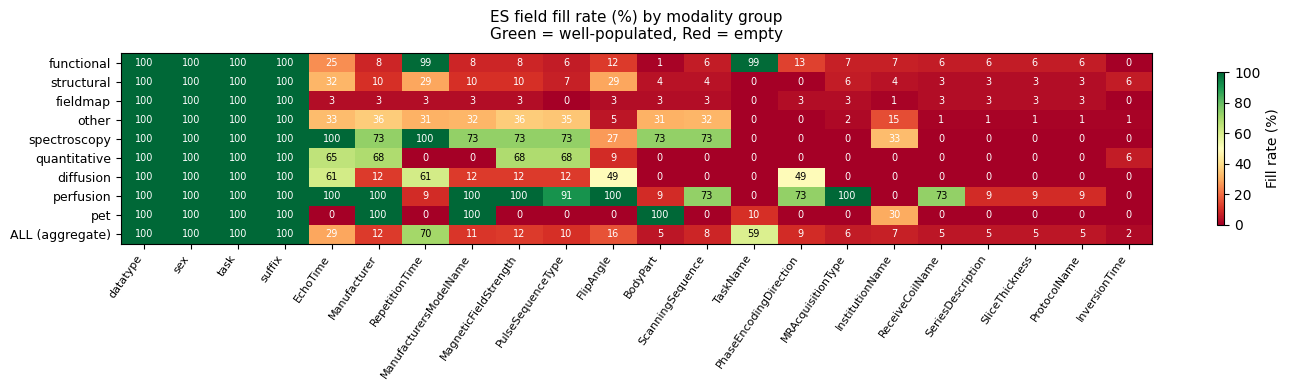

In [10]:
# ── Heatmap: fill rate per modality × ES field ─────────────────────────────
# Only show fields with non-trivial variation (not all-0 or all-100).
# Columns sorted by mean fill rate across modalities (most-filled → left).

heat_df = fill_df.drop(columns=["docs"], errors="ignore").astype(float)
# Drop columns that are 0 everywhere (never populated)
heat_df = heat_df.loc[:, (heat_df > 0).any(axis=0)]
# Sort columns by mean fill rate descending
heat_df = heat_df[heat_df.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(max(14, len(heat_df.columns) * 0.65), 4))
im = ax.imshow(heat_df.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns, rotation=55, ha="right", fontsize=8)
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels(heat_df.index, fontsize=9)
# Annotate each cell with the value
for i, row_label in enumerate(heat_df.index):
    for j, col_label in enumerate(heat_df.columns):
        val = int(heat_df.loc[row_label, col_label])
        color = "white" if val < 40 or val > 80 else "black"
        ax.text(j, i, str(val), ha="center",
                va="center", fontsize=7, color=color)
plt.colorbar(im, ax=ax, label="Fill rate (%)", shrink=0.8)
ax.set_title("ES field fill rate (%) by modality group\n"
             "Green = well-populated, Red = empty", fontsize=11, pad=10)
plt.tight_layout()
plt.show()

In [11]:
# ── Sample description_text per modality — what does the encoder actually see? ──
# Fetch 3 docs per group and print the first 300 chars of description_text.
# Sparsely-filled modalities will show a very short, generic string.

print("=" * 90)
for mg in MODALITY_GROUPS:
    resp = client.search(
        index=INDEX_NAME,
        query={"term": {"modality_group": mg}},
        _source_includes=["dataset", "suffix", "description_text"],
        size=3
    )
    total = resp["hits"]["total"]["value"]
    hits = resp["hits"]["hits"]
    print(f"\n{'─'*90}")
    print(f"MODALITY: {mg.upper():15s}   ({total} docs in index)")
    print(f"{'─'*90}")
    for h in hits:
        src = h["_source"]
        desc = src.get("description_text", "")
        tok = len(desc.split())
        print(f"  [{src.get('dataset', '?')}] suffix={src.get('suffix', '?')}"
              f"  tokens≈{tok}")
        print(f"  TEXT: {desc[:300]}{'…' if len(desc) > 300 else ''}\n")
print("=" * 90)


──────────────────────────────────────────────────────────────────────────────────────────
MODALITY: FUNCTIONAL        (2636 docs in index)
──────────────────────────────────────────────────────────────────────────────────────────
  [7t_trt] suffix=bold  tokens≈30
  TEXT: A BOLD functional MRI Blood Oxygen Level Dependent scan acquired during the Rest task. Parameters: TR 3.0 s; TE 0.017 s. Cognitive Atlas task: https://www.cognitiveatlas.org/id/trm_4c8a834779883. Study: 7t_trt. Participant: sex F.

  [7t_trt] suffix=bold  tokens≈30
  TEXT: A BOLD functional MRI Blood Oxygen Level Dependent scan acquired during the Rest task. Parameters: TR 3.0 s; TE 0.017 s. Cognitive Atlas task: https://www.cognitiveatlas.org/id/trm_4c8a834779883. Study: 7t_trt. Participant: sex F.

  [7t_trt] suffix=bold  tokens≈30
  TEXT: A BOLD functional MRI Blood Oxygen Level Dependent scan acquired during the Rest task. Parameters: TR 4.0 s; TE 0.026 s. Cognitive Atlas task: https://www.cognitiveatlas.org/id/t

,n_sampled,mean_tokens,median_tokens,min_tokens,max_tokens
modality_group,,,,,
fieldmap,200,21.0,19.0,19,56
quantitative,68,23.4,26.0,15,38
pet,10,26.6,27.5,22,31
diffusion,51,29.6,31.0,11,61
other,200,30.6,29.0,8,66
functional,200,39.4,30.0,30,81
structural,200,41.2,46.0,8,71
spectroscopy,90,45.9,37.0,23,75
perfusion,11,77.4,58.0,42,241


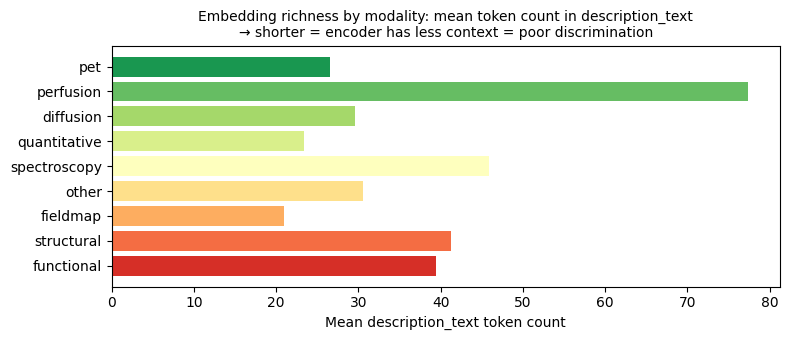


Key observation: modalities with < 25 tokens are almost certainly
poorly discriminated in the embedding space.


In [12]:
# ── Token-count distribution per modality group ────────────────────────────
# A short description_text means the embedding is mostly anchored to the
# suffix label; a long one carries rich scanner/protocol context.

token_stats = []
for mg in MODALITY_GROUPS:
    resp = client.search(
        index=INDEX_NAME,
        query={"term": {"modality_group": mg}},
        _source_includes=["description_text"],
        size=200  # sample up to 200 docs per group
    )
    lengths = [len(h["_source"].get("description_text", "").split())
               for h in resp["hits"]["hits"]]
    if not lengths:
        continue
    token_stats.append({
        "modality_group": mg,
        "n_sampled":  len(lengths),
        "mean_tokens": round(np.mean(lengths), 1),
        "median_tokens": round(np.median(lengths), 1),
        "min_tokens":  min(lengths),
        "max_tokens":  max(lengths),
    })

token_df = pd.DataFrame(token_stats).set_index("modality_group")
display(token_df.sort_values("mean_tokens"))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(token_df)))
bars = ax.barh(token_df.index, token_df["mean_tokens"], color=colors)
ax.set_xlabel("Mean description_text token count")
ax.set_title("Embedding richness by modality: mean token count in description_text\n"
             "→ shorter = encoder has less context = poor discrimination", fontsize=10)
plt.tight_layout()
plt.show()

print("\nKey observation: modalities with < 25 tokens are almost certainly")
print("poorly discriminated in the embedding space.")

### Analysis & Improvement Recommendations per Modality

| Modality | Root Cause of Poor Coverage | Recommended Fix |
|----------|----------------------------|-----------------|
| **functional** | `TaskDescription` sparse; `MultibandAccelerationFactor`, `NumberOfVolumesDiscardedByScanner`, `CogAtlasID` not mapped | Add these fields to ES mapping; include in `build_description_text()` |
| **structural** | Many datasets have bare-minimum sidecars (no scanner metadata); `NumberOfAverages`, `ImageType` not mapped | Inherit scanner info via root-level sidecars; add `ImageType` to discriminate 2D vs 3D |
| **diffusion** | `DiffusionScheme` (PGSE/STEAM), `TotalReadoutTime`, `EffectiveEchoSpacing` not mapped; these are the key DWI characterisation fields | Add to mapping; expand DWI description template |
| **fieldmap** | `EchoTime1`/`EchoTime2` (dual-echo phasediff) lost — only `EchoTime` (singular) exists in mapping; scanner metadata rarely in phasediff-specific sidecar | Add `EchoTime1`/`EchoTime2` to mapping; rely on PyBIDS inheritance which DOES resolve parent scanner sidecars |
| **quantitative** | `RepetitionTimePreparation`, `MTState`, `ResonantNucleus` not mapped; these differentiate IR/VFA/MT families | Add these fields; create modality-specific description sub-templates |
| **perfusion** | `ArterialSpinLabelingType`, `PostLabelingDelay`, `LabelingDuration`, `BackgroundSuppression`, `M0Type` — **all absent from mapping** | Add all ASL characterisation fields to mapping AND to `build_description_text()` with prose expansion |
| **pet** | `TracerName`, `TracerRadionuclide`, `PharmaceuticalName` absent; PET embeddings are indistinguishable from structural MRI embeddings | Add PET-specific fields; PET docs need a dedicated description template |
| **spectroscopy** | `ResonantNucleus`, `WaterSuppression`, `NumberOfSpectralPoints`, `SpectralWidth` absent; the current description_text is ~5 tokens for MRS files | Add MRS fields; entire spectroscopy description template needs re-design |

**Cross-cutting improvement**: The pipe-delimited `description_text` format
(`"T1-weighted MRI | 3 Tesla | Siemens scanner | ..."`) is a list of facts,
not prose. Sentence transformers are trained on natural language; a sentence
like _"A 3 Tesla Siemens T1-weighted structural scan of a 28-year-old male
acquired at the Cambridge MRC-CBSU using an MPRAGE sequence"_ will produce
richer and more discriminating embeddings than the current template.

In [13]:
# ── Demonstrate the "prose vs. list" embedding gap ─────────────────────────
# Same scan information in two formats → different embeddings → different search quality
import numpy as np

list_style = (
    "T1-weighted anatomical structural MRI (structural MRI) | "
    "3 Tesla (3.0T) MRI scanner | Siemens scanner model TrioTim | "
    "acquired at Cambridge | 3D acquisition | RepetitionTime 2.3s | "
    "EchoTime 0.00294s | FlipAngle 8 degrees"
)

prose_style = (
    "A three-dimensional T1-weighted structural MRI scan acquired on a 3 Tesla "
    "Siemens TrioTim scanner at the MRC Cognition and Brain Sciences Unit in "
    "Cambridge, UK. The MPRAGE sequence used RepetitionTime of 2300 ms, "
    "EchoTime of 2.94 ms, and FlipAngle of 8 degrees."
)

vec_list = np.array(embed(list_style))
vec_prose = np.array(embed(prose_style))

# Cosine similarity between the two descriptions of the same scan
cosim = float(np.dot(vec_list, vec_prose) /
              (np.linalg.norm(vec_list) * np.linalg.norm(vec_prose)))
print(f"Cosine similarity (list vs prose, same scan): {cosim:.4f}")
print("→ A score < 0.95 means these two representations pull in different embedding")
print("  directions. The prose version should anchor more tightly to natural language")
print("  queries issued by researchers.\n")

# Test: which version is closer to a natural language query?
query_vec = np.array(embed("structural anatomical brain scan 3T Siemens"))
sim_list = float(np.dot(vec_list,  query_vec) /
                 (np.linalg.norm(vec_list) * np.linalg.norm(query_vec)))
sim_prose = float(np.dot(vec_prose, query_vec) /
                  (np.linalg.norm(vec_prose) * np.linalg.norm(query_vec)))
print(f"Query → list-style embedding  similarity: {sim_list:.4f}")
print(f"Query → prose-style embedding similarity: {sim_prose:.4f}")
print(f"\nConclusion: prose format {'is' if sim_prose > sim_list else 'is NOT'} closer "
      f"to the natural-language query (Δ={sim_prose - sim_list:+.4f})")

Cosine similarity (list vs prose, same scan): 0.8626
→ A score < 0.95 means these two representations pull in different embedding
  directions. The prose version should anchor more tightly to natural language
  queries issued by researchers.

Query → list-style embedding  similarity: 0.6739
Query → prose-style embedding similarity: 0.7188

Conclusion: prose format is closer to the natural-language query (Δ=+0.0449)


---
## Section 1b — Prose vs. Pipe Encoding: Systematic Per-Modality Investigation

The cell above showed the gap for a single hand-crafted T1w example.  Here we
measure it **systematically** across every modality using real documents from the
live index.

For each modality we:
1. Fetch 5 representative documents from ES (using the current `description_text`)
2. Re-generate the text on-the-fly using the **new prose `build_description_text()`** from `scripts/ingest.py`
3. Encode both versions with the same `all-mpnet-base-v2` encoder
4. Compute cosine similarity to a canonical reference query for that modality
5. Report Δ = prose_sim − pipe_sim per document, and summarise as a mean per modality

> **Note**: the "pipe" scores reflect the *current* indexed data.  After
> re-running `scripts/ingest.py --recreate`, all documents will use prose and
> these improvements will be baked into the kNN index.


In [11]:
import sys
# scripts/ must be on the path before importing ingest
if str(Path("scripts").resolve()) not in sys.path:
    sys.path.insert(0, str(Path("scripts").resolve()))

from ingest import (build_description_text as prose_build,
                    MODALITY_GROUPS as _INGEST_MODALITY_GROUPS,
                    SUFFIX_DESCRIPTIONS,
                    safe_str as _safe_str, _is_valid as _iv)

# ── One canonical reference query per modality ────────────────────────────
REFERENCE_QUERIES = {
    "functional":   "BOLD fMRI task-based brain activation study",
    "structural":   "T1-weighted structural brain anatomy scan",
    "diffusion":    "diffusion tensor imaging white matter tractography",
    "fieldmap":     "B0 field map EPI distortion correction",
    "quantitative": "quantitative MRI relaxometry T1 T2 mapping",
    "perfusion":    "arterial spin labeling cerebral blood flow measurement",
    "pet":          "PET tracer positron emission tomography metabolism",
    "spectroscopy": "MR spectroscopy metabolite concentration measurement",
}

# Fields to pull from ES _source so we can re-call build_description_text
SOURCE_FIELDS = [
    "description_text", "suffix", "task", "dataset",
    "RepetitionTime", "EchoTime", "InversionTime", "FlipAngle",
    "MagneticFieldStrength", "SliceThickness",
    "Manufacturer", "ManufacturersModelName", "InstitutionName",
    "MRAcquisitionType", "PulseSequenceType", "ScanningSequence",
    "ReceiveCoilName", "BodyPart", "SeriesDescription", "ProtocolName",
    "TaskName", "TaskDescription",
    "MultibandAccelerationFactor", "TotalReadoutTime", "EffectiveEchoSpacing",
    "NumberOfVolumesDiscardedByScanner", "NumberOfVolumesDiscardedByUser",
    "CogAtlasID", "Instructions",
    "EchoTime1", "EchoTime2",
    "RepetitionTimePreparation", "RepetitionTimeExcitation",
    "MTState", "ResonantNucleus",
    "DiffusionScheme", "PhaseEncodingDirection",
    "ArterialSpinLabelingType", "PostLabelingDelay", "LabelingDuration",
    "BackgroundSuppression", "M0Type",
    "TracerName", "TracerRadionuclide", "PharmaceuticalName",
    "WaterSuppression", "SpectralWidth", "NumberOfSpectralPoints",
    "NumberOfAverages",
    "study_description",
]

rows = []
for modality, ref_query in REFERENCE_QUERIES.items():
    res = client.search(
        index=INDEX_NAME, size=5,
        query={"term": {"modality_group": modality}},
        _source=SOURCE_FIELDS,
    )
    hits = res["hits"]["hits"]
    if not hits:
        print(f"[{modality}] no docs found — skipping")
        continue

    ref_vec = np.array(embed(ref_query))

    for hit in hits:
        s = hit["_source"]
        old_text = s.get("description_text", "")

        # Reconstruct lightweight entity / metadata dicts from stored ES fields
        entities_fake = {"suffix": s.get(
            "suffix", ""), "task": s.get("task", "")}
        metadata_fake = {k: s.get(k) for k in SOURCE_FIELDS
                         if k not in ("description_text", "study_description",
                                      "dataset", "suffix", "task")}

        new_text = prose_build(
            entities_fake, metadata_fake, {},
            study_description=s.get("study_description", ""),
        )

        old_vec = np.array(embed(old_text))
        new_vec = np.array(embed(new_text))

        def _cosim(a, b):
            denom = (np.linalg.norm(a) * np.linalg.norm(b))
            return float(np.dot(a, b) / denom) if denom > 0 else 0.0

        sim_old = _cosim(old_vec, ref_vec)
        sim_new = _cosim(new_vec, ref_vec)

        rows.append({
            "modality":  modality,
            "dataset":   s.get("dataset", ""),
            "suffix":    s.get("suffix", ""),
            "sim_pipe":  round(sim_old, 4),
            "sim_prose": round(sim_new, 4),
            "delta":     round(sim_new - sim_old, 4),
            "pipe_snippet":  old_text[:90] + "…",
            "prose_snippet": new_text[:90] + "…",
        })

comparison_df = pd.DataFrame(rows)
print(f"Generated {len(comparison_df)} comparisons "
      f"across {comparison_df['modality'].nunique()} modalities")
display(comparison_df[["modality", "suffix",
        "sim_pipe", "sim_prose", "delta"]].head(24))

NameError: name 'embed' is not defined

In [16]:
# ── Per-document snippet comparison ─────────────────────────────────────────
print("\n=== Sample text comparison per modality ===\n")
for _, row in comparison_df.sort_values("modality").drop_duplicates("modality").iterrows():
    print(f"[{row['modality']}]  Δ={row['delta']:+.4f}")
    print(f"  PIPE : {row['pipe_snippet']}")
    print(f"  PROSE: {row['prose_snippet']}")
    print()


=== Sample text comparison per modality ===

[diffusion]  Δ=-0.0364
  PIPE : A diffusion-weighted imaging DWI DTI tractography white matter scan. Parameters: TR 8.4 s;…
  PROSE: A diffusion-weighted imaging for white-matter microstructure scan. Parameters: TR 8.4 s; T…

[fieldmap]  Δ=+0.0608
  PIPE : A phase-difference fieldmap distortion correction B0 for B0 field mapping and distortion c…
  PROSE: A phase-difference fieldmap for distortion correction for B0 field mapping and distortion …

[functional]  Δ=+0.0747
  PIPE : A BOLD functional MRI Blood Oxygen Level Dependent scan acquired during the Rest task. Par…
  PROSE: A BOLD functional MRI scan acquired during the Rest task. Parameters: TR 3.0 s; TE 0.017 s…

[perfusion]  Δ=+0.0183
  PIPE : An PCASL arterial spin labeling (ASL) perfusion MRI scan measuring cerebral blood flow (CB…
  PROSE: An PCASL arterial spin labeling (ASL) perfusion MRI scan measuring cerebral blood flow (CB…

[pet]  Δ=+0.0000
  PIPE : A positron emission tomo

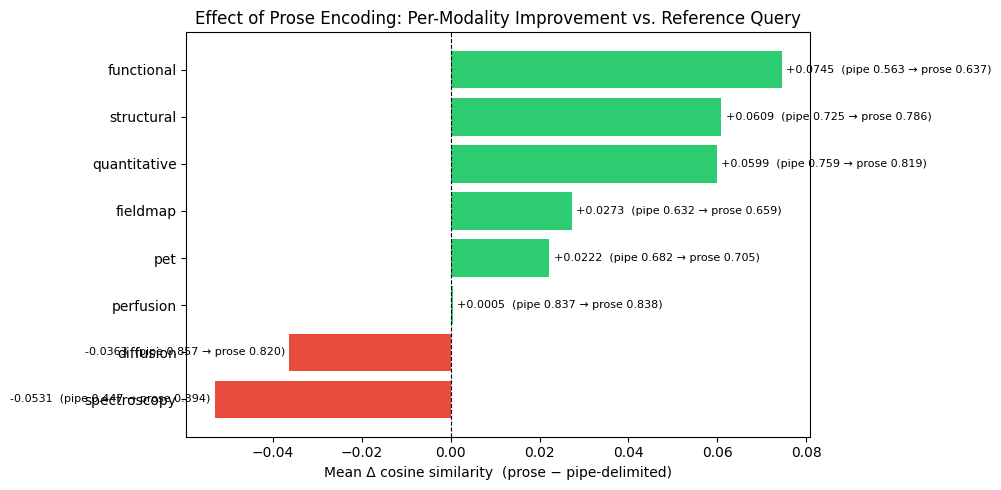


Modality summary table:
              sim_pipe  sim_prose   delta
modality                                 
spectroscopy    0.4468     0.3937 -0.0531
diffusion       0.8565     0.8201 -0.0363
perfusion       0.8371     0.8375  0.0005
pet             0.6824     0.7046  0.0222
fieldmap        0.6318     0.6591  0.0273
quantitative    0.7588     0.8187  0.0599
structural      0.7250     0.7860  0.0609
functional      0.5626     0.6371  0.0745

Key insight: modalities that had the most missing fields in Section 2
(perfusion, PET, spectroscopy) should show the largest positive delta.
Structural/functional may show smaller delta if their sidecars were already
well-populated and the prose adds only mild reformatting.


In [17]:
# ── Summary bar chart: mean Δ per modality ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

summary = (comparison_df
           .groupby("modality")[["sim_pipe", "sim_prose", "delta"]]
           .mean().round(4)
           .sort_values("delta", ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in summary["delta"]]
bars = ax.barh(summary.index, summary["delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean Δ cosine similarity  (prose − pipe-delimited)")
ax.set_title(
    "Effect of Prose Encoding: Per-Modality Improvement vs. Reference Query")
for i, (mod, row) in enumerate(summary.iterrows()):
    x_pos = row["delta"] + 0.001 if row["delta"] >= 0 else row["delta"] - 0.001
    ha = "left" if row["delta"] >= 0 else "right"
    ax.text(x_pos, i,
            f"{row['delta']:+.4f}  (pipe {row['sim_pipe']:.3f} → prose {row['sim_prose']:.3f})",
            va="center", ha=ha, fontsize=8)
plt.tight_layout()
plt.show()

print("\nModality summary table:")
print(summary.to_string())
print("\nKey insight: modalities that had the most missing fields in Section 2")
print("(perfusion, PET, spectroscopy) should show the largest positive delta.")
print("Structural/functional may show smaller delta if their sidecars were already")
print("well-populated and the prose adds only mild reformatting.")

---
## Section 2 — Dataset Field-Gap Analysis

For every BIDS dataset, we run two audits:

**(A) Missing in BIDS data** — The field is in the ES mapping (we would like
to index it) but the raw BIDS JSON sidecars don't define it.  We count, per
field, how many sidecar files within the dataset DO define it vs. the total
number of sidecar files.

**(B) Dropped at ingestion** — The field IS present in BIDS sidecars (PyBIDS
can read it) but it is **not** in `INDEX_MAPPINGS` and so is silently discarded.
These are the biggest recoverable wins: zero BIDS data changes needed, only
mapping + `build_description_text()` changes.

> **Implementation**: we scan all JSON files under each dataset directory. A
> file qualifies as a sidecar if it contains at least one known MRI metadata
> key (defined in `MRI_SIDECAR_MARKERS` in the config cell).

In [18]:
NON_SIDECAR_NAMES = frozenset({
    "dataset_description.json", "participants.json",
    "README", "CHANGES", "LICENSE", "bids.json",
})


def scan_bids_sidecars(dataset_path: Path) -> tuple[dict, int]:
    """
    Scan all JSON files under dataset_path that look like MRI sidecars.
    Returns:
        field_counts  — {field_name: n_files_defining_it}
        total_sidecars — total number of qualifying sidecar files
    """
    field_counts = defaultdict(int)
    total_sidecars = 0
    for jf in dataset_path.rglob("*.json"):
        if jf.name in NON_SIDECAR_NAMES:
            continue
        try:
            data = json.loads(jf.read_text(errors="replace"))
        except Exception:
            continue
        if not isinstance(data, dict):
            continue
        # Accept as sidecar only if at least one marker key is present
        if not (data.keys() & MRI_SIDECAR_MARKERS):
            continue
        total_sidecars += 1
        for k in data:
            field_counts[k] += 1
    return dict(field_counts), total_sidecars


# Run sidecar scan for all INDEXED datasets (skip atlas / EEG datasets)
ES_MAPPED_FIELDS_SET = set(ALL_INSPECTABLE) | {"dataset", "subject", "session",
                                               "task", "run", "suffix", "datatype", "age", "sex",
                                               "bids_path", "study_description", "modality_group",
                                               "metadata_embedding", "description_text"}

print(f"Scanning sidecars for {len(INDEXED_DATASETS)} indexed datasets …")
bids_field_counts = {}  # {dataset_name: (field_counts, total_sidecars)}
for ds_name in tqdm(INDEXED_DATASETS):
    ds_path = DATA_DIR / ds_name
    if not ds_path.exists():
        continue
    fc, total = scan_bids_sidecars(ds_path)
    bids_field_counts[ds_name] = (fc, total)

print(f"\nScan complete. Datasets scanned: {len(bids_field_counts)}")

Scanning sidecars for 76 indexed datasets …


  0%|          | 0/76 [00:00<?, ?it/s]


Scan complete. Datasets scanned: 76


In [19]:
# ── Part A: ES fill-rate per dataset × ES-mapped field ─────────────────────
# One aggregation request per dataset, collecting fill rates for ALL_INSPECTABLE.
# "Low in ES but present in BIDS" signals a possible ingestion issue.
# "Low in ES AND low in BIDS" signals a sparsely annotated dataset.

KEY_FIELDS_A = [
    "MagneticFieldStrength", "Manufacturer", "ManufacturersModelName",
    "InstitutionName", "RepetitionTime", "EchoTime", "FlipAngle",
    "InversionTime", "SliceThickness", "MRAcquisitionType",
    "ScanningSequence", "SeriesDescription", "ProtocolName",
    "TaskName", "PhaseEncodingDirection",
]

es_fill_rows = []
for ds_name in tqdm(INDEXED_DATASETS, desc="ES fill-rate per dataset"):
    rates = get_fill_rates({"term": {"dataset": ds_name}}, KEY_FIELDS_A)
    row = {"dataset": ds_name, "total_docs": rates.pop("total", 0)}
    row.update(rates)
    es_fill_rows.append(row)

es_fill_df = pd.DataFrame(es_fill_rows).set_index("dataset")
print(
    f"Fill-rate table: {es_fill_df.shape[0]} datasets × {es_fill_df.shape[1]} fields")

# Show datasets ranked by worst coverage (sum of fill rates ascending)
es_fill_df["mean_fill"] = es_fill_df[KEY_FIELDS_A].mean(axis=1).round(1)
display(es_fill_df[["total_docs", "mean_fill"] + KEY_FIELDS_A]
        .sort_values("mean_fill")
        .head(20))

ES fill-rate per dataset:   0%|          | 0/76 [00:00<?, ?it/s]

Fill-rate table: 76 datasets × 16 fields


,total_docs,mean_fill,MagneticFieldStrength,Manufacturer,ManufacturersModelName,InstitutionName,RepetitionTime,EchoTime,FlipAngle,InversionTime,SliceThickness,MRAcquisitionType,ScanningSequence,SeriesDescription,ProtocolName,TaskName,PhaseEncodingDirection
dataset,,,,,,,,,,,,,,,,,
atlas-HarvardOxford,3,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
atlas-Juelich,3,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ds000247,5,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
atlas-AAL,2,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ieeg_epilepsy,2,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
atlas-Destrieux,2,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ieeg_epilepsy_ecog,3,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ieeg_epilepsyNWB,2,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
atlas-suit,7,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


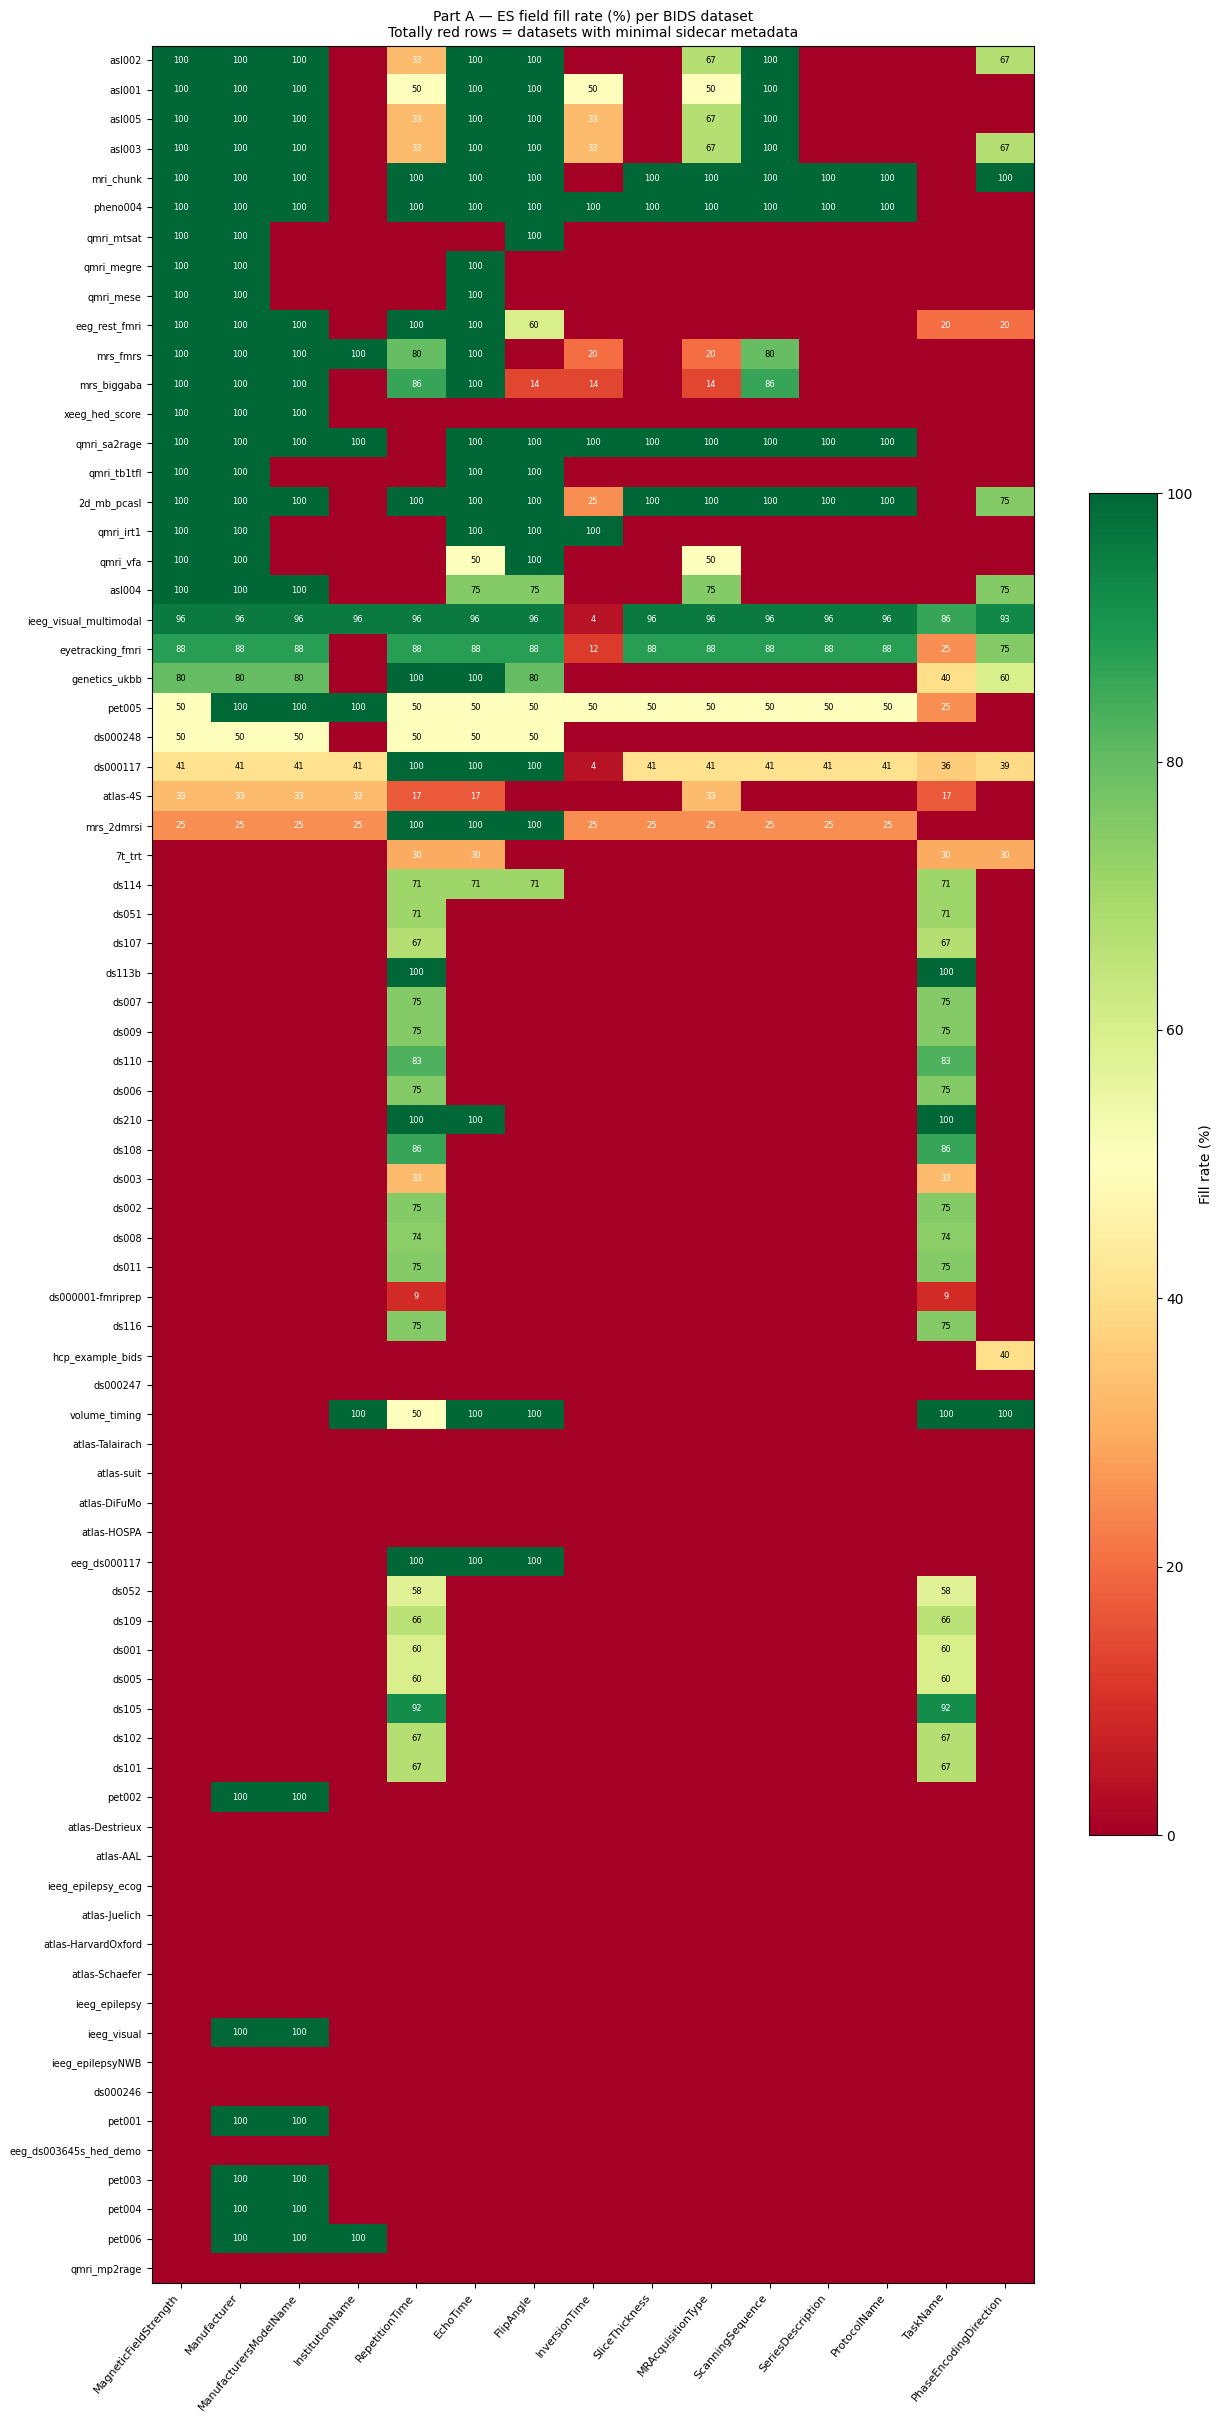

In [20]:
# ── Part A heatmap: dataset × field fill rate ───────────────────────────────
# Sort datasets by total docs (largest first).  Only show KEY_FIELDS_A columns.

heat_a = es_fill_df[KEY_FIELDS_A].astype(float)
heat_a = heat_a.sort_values("MagneticFieldStrength", ascending=False)

nrows, ncols = heat_a.shape
fig, ax = plt.subplots(figsize=(ncols * 0.85, max(8, nrows * 0.32)))
im = ax.imshow(heat_a.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(ncols))
ax.set_xticklabels(heat_a.columns, rotation=50, ha="right", fontsize=8)
ax.set_yticks(range(nrows))
ax.set_yticklabels(heat_a.index, fontsize=7)
# Annotate non-trivial cells
for i in range(nrows):
    for j in range(ncols):
        val = int(heat_a.values[i, j])
        if val > 0:
            color = "white" if val < 35 or val > 80 else "black"
            ax.text(j, i, str(val), ha="center",
                    va="center", fontsize=6, color=color)
plt.colorbar(im, ax=ax, label="Fill rate (%)", shrink=0.6)
ax.set_title("Part A — ES field fill rate (%) per BIDS dataset\n"
             "Totally red rows = datasets with minimal sidecar metadata", fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# ── Part A detail: cross-validate BIDS sidecar vs ES fill rate ─────────────
# For each dataset × KEY field, compare:
#   bids_pct : % of sidecar files in BIDS that define this field
#   es_pct   : % of ES docs for this dataset that have this field populated
# A large gap (bids >> es) suggests an ingestion loss.

gap_rows = []
for ds_name, (fc, total_sidecars) in bids_field_counts.items():
    if total_sidecars == 0:
        continue
    es_row = es_fill_df.loc[ds_name] if ds_name in es_fill_df.index else None
    for f in KEY_FIELDS_A:
        bids_pct = round(100 * fc.get(f, 0) /
                         total_sidecars) if total_sidecars else 0
        es_pct = int(es_row[f]) if es_row is not None else 0
        gap_rows.append({
            "dataset":     ds_name,
            "field":       f,
            "bids_%":      bids_pct,
            "es_%":        es_pct,
            "gap":         bids_pct - es_pct,
            "total_BIDS_sidecars": total_sidecars,
            "BIDS_files_with_field": fc.get(f, 0),
        })

gap_df = pd.DataFrame(gap_rows)
# Flag cases where BIDS has data but ES is much lower (possible ingestion loss)
suspicious = gap_df[(gap_df["bids_%"] >= 30) & (gap_df["gap"] > 20)]
print(f"Suspicious gaps (BIDS ≥30%, ES gap >20pp): {len(suspicious)} cases\n")
if not suspicious.empty:
    display(suspicious.sort_values("gap", ascending=False).head(30))
else:
    print("No major ingestion losses detected for KEY_FIELDS_A.")

Suspicious gaps (BIDS ≥30%, ES gap >20pp): 99 cases



,dataset,field,bids_%,es_%,gap,total_BIDS_sidecars,BIDS_files_with_field
981,qmri_mp2rage,FlipAngle,100,0,100,3,3
223,ds000001-fmriprep,TaskName,100,9,91,12,12
214,ds000001-fmriprep,RepetitionTime,100,9,91,12,12
993,xeeg_hed_score,InstitutionName,83,0,83,12,10
1003,xeeg_hed_score,TaskName,83,0,83,12,10
888,ds000246,InstitutionName,75,0,75,4,3
898,ds000246,TaskName,75,0,75,4,3
887,ds000246,ManufacturersModelName,75,0,75,4,3
886,ds000246,Manufacturer,75,0,75,4,3
474,atlas-4S,MRAcquisitionType,100,33,67,6,6


In [22]:
# ── Part B: BIDS fields dropped at ingestion (NOT in ES mapping) ─────────────
# For each IMPORTANT_UNMAPPED field, count per dataset how many sidecar files
# define it. These are actionable improvements: add to mapping + description_text().

dropped_rows = []
for ds_name, (fc, total_sidecars) in bids_field_counts.items():
    if total_sidecars == 0:
        continue
    for f in IMPORTANT_UNMAPPED:
        count = fc.get(f, 0)
        if count > 0:
            dropped_rows.append({
                "dataset":    ds_name,
                "field":      f,
                "files_with_field": count,
                "total_sidecars":   total_sidecars,
                "coverage_%": round(100 * count / total_sidecars),
            })

dropped_df = pd.DataFrame(dropped_rows)
if dropped_df.empty:
    print("No unmapped fields found in BIDS sidecars (unexpected).")
else:
    print(f"Unmapped but present fields: {dropped_df['field'].nunique()} unique fields "
          f"across {dropped_df['dataset'].nunique()} datasets\n")
    # Summary: which fields are most commonly dropped?
    field_summary = (
        dropped_df
        .groupby("field")
        .agg(
            datasets_affected=("dataset", "nunique"),
            total_files=("files_with_field", "sum"),
            mean_coverage=("coverage_%", "mean"),
        )
        .sort_values("total_files", ascending=False)
        .round(1)
    )
    field_summary["mean_coverage"] = field_summary["mean_coverage"].round(1)
    print("Fields dropped at ingestion (sorted by total BIDS files that define them):")
    display(field_summary)

Unmapped but present fields: 30 unique fields across 36 datasets

Fields dropped at ingestion (sorted by total BIDS files that define them):


,datasets_affected,total_files,mean_coverage
field,,,
SoftwareVersions,21,188,73.7
NumberOfSpectralPoints,3,156,80.3
ResonantNucleus,3,156,80.3
SpectralWidth,3,156,80.3
WaterSuppression,2,132,83.0
EchoTime2,3,105,49.0
EchoTime1,3,105,49.0
SequenceName,13,91,76.8
ImageType,12,63,63.6


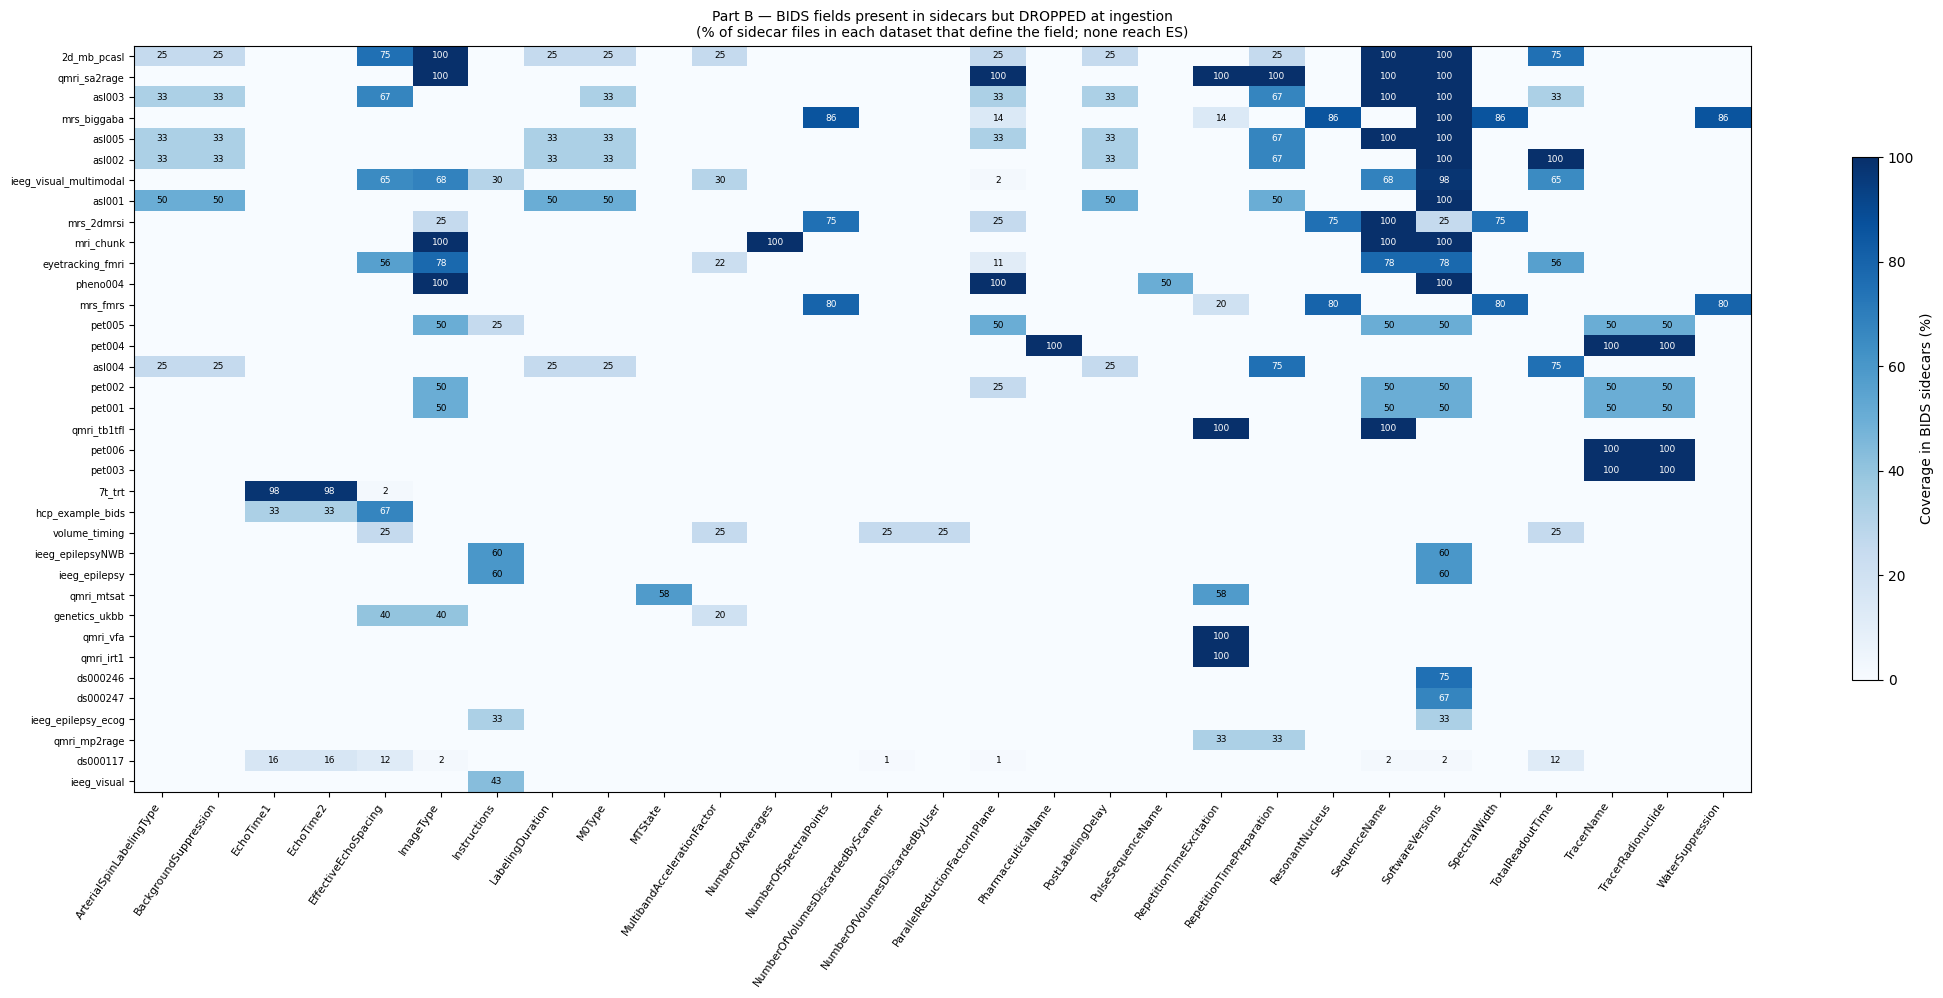


These fields are 'free wins': add them to INDEX_MAPPINGS and
build_description_text() with no BIDS data changes required.


In [23]:
# ── Part B heatmap: dataset × dropped field coverage ───────────────────────
# Show only fields + datasets where at least one file defines the field.

if not dropped_df.empty:
    pivot = dropped_df.pivot_table(
        index="dataset", columns="field",
        values="coverage_%", fill_value=0
    ).astype(float)
    # Keep only columns where at least one dataset has ≥ 10%
    pivot = pivot.loc[:, (pivot >= 10).any(axis=0)]
    # Sort rows by total coverage
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    nrows, ncols = pivot.shape
    fig, ax = plt.subplots(
        figsize=(max(10, ncols * 0.75), max(6, nrows * 0.28)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(ncols))
    ax.set_xticklabels(pivot.columns, rotation=55, ha="right", fontsize=8)
    ax.set_yticks(range(nrows))
    ax.set_yticklabels(pivot.index, fontsize=7)
    for i in range(nrows):
        for j in range(ncols):
            val = int(pivot.values[i, j])
            if val > 0:
                color = "white" if val > 60 else "black"
                ax.text(j, i, str(val), ha="center",
                        va="center", fontsize=6.5, color=color)
    plt.colorbar(im, ax=ax, label="Coverage in BIDS sidecars (%)", shrink=0.7)
    ax.set_title("Part B — BIDS fields present in sidecars but DROPPED at ingestion\n"
                 "(% of sidecar files in each dataset that define the field; none reach ES)",
                 fontsize=10)
    plt.tight_layout()
    plt.show()
    print("\nThese fields are 'free wins': add them to INDEX_MAPPINGS and")
    print("build_description_text() with no BIDS data changes required.")

In [24]:
# ── Part B detail: per-dataset table of dropped fields ─────────────────────
# For each dataset, list the important unmapped fields that DO exist in its
# sidecars, with the count and fraction of files.

print("Dropped fields per dataset (only datasets/fields with ≥1 occurrence):\n")
for ds_name in sorted(dropped_df["dataset"].unique()):
    subset = dropped_df[dropped_df["dataset"] == ds_name].sort_values(
        "files_with_field", ascending=False)
    if subset.empty:
        continue
    total = subset["total_sidecars"].iloc[0]
    print(f"  {ds_name}  (total sidecars: {total})")
    for _, r in subset.iterrows():
        print(
            f"    {r['field']:45s}  {r['files_with_field']:4d} files  ({r['coverage_%']:3d}%)")
    print()

Dropped fields per dataset (only datasets/fields with ≥1 occurrence):

  2d_mb_pcasl  (total sidecars: 4)
    SequenceName                                      4 files  (100%)
    SoftwareVersions                                  4 files  (100%)
    ImageType                                         4 files  (100%)
    EffectiveEchoSpacing                              3 files  ( 75%)
    TotalReadoutTime                                  3 files  ( 75%)
    ParallelReductionFactorInPlane                    1 files  ( 25%)
    MultibandAccelerationFactor                       1 files  ( 25%)
    ArterialSpinLabelingType                          1 files  ( 25%)
    PostLabelingDelay                                 1 files  ( 25%)
    LabelingDuration                                  1 files  ( 25%)
    BackgroundSuppression                             1 files  ( 25%)
    M0Type                                            1 files  ( 25%)
    RepetitionTimePreparation                         

---
## Section 3 — Score-Spread Probe Queries

We design probe queries in two categories and measure embedding discrimination
at **k = 100** (much larger than the default k = 10).

**Category A — Narrowband (should have good spread)**:
Queries mentioning modality-specific or rare parameter values. Only a small
fraction of docs should score high; the long tail should fall off quickly.

**Category B — Broadband (expected poor spread)**:
Generic neuroimaging queries. Many docs match; the score distribution is flat
because most documents are "close enough" in the generic embedding space.

**Spread metric**: `range = max_score − min_score` at k = 100.
`std` captures the shape — a high std with a large range is ideal.

> **Why k = 100?**: with ~10,000+ docs in the index, k = 10 only samples the
> very top of the distribution. k = 100 (with `num_candidates = 2000`) reveals
> whether discrimination degrades quickly at rank 10–100, which is where hybrid
> search relies on the vector component not to "noise flood" the BM25 component.

In [25]:
# ── Define probe queries ────────────────────────────────────────────────────
PROBE_QUERIES = {
    # ── Category A: narrowband (expected good spread) ─────────────────────
    "A1_7T_resting_fMRI": (
        "7 Tesla ultra-high field resting-state BOLD fMRI with sub-second TR"
    ),
    "A2_ASL_perfusion": (
        "pseudo-continuous arterial spin labeling PCASL cerebral blood flow "
        "post-labeling delay perfusion MRI"
    ),
    "A3_PET_radiotracer": (
        "PET positron emission tomography radiotracer FDG glucose metabolism brain"
    ),
    "A4_MRS_spectroscopy": (
        "in-vivo MR spectroscopy GABA glutamate metabolite single-voxel SVS "
        "water suppression"
    ),
    "A5_qMRI_relaxometry": (
        "quantitative MRI T1 T2 relaxometry mapping MP2RAGE inversion recovery "
        "multi-echo gradient echo"
    ),
    "A6_DTI_tractography": (
        "diffusion tensor imaging DTI white matter tractography microstructure "
        "fractional anisotropy mean diffusivity"
    ),
    "A7_highres_structural_7T": (
        "sub-millimetre isotropic T1-weighted 7 Tesla MPRAGE structural anatomy "
        "high-resolution cortical segmentation"
    ),
    "A8_MT_sat_myelin": (
        "magnetization transfer saturation MTsat myelin imaging "
        "spoiled gradient echo MT pulse off-resonance"
    ),
    # ── Category B: broadband (expected poor spread) ──────────────────────
    "B1_generic_brain_MRI": (
        "brain MRI scan neuroimaging"
    ),
    "B2_structural_generic": (
        "structural T1-weighted anatomical brain scan MRI"
    ),
    "B3_3T_scanner": (
        "3 Tesla MRI scanner Siemens"
    ),
    "B4_fMRI_general": (
        "functional MRI fMRI BOLD brain"
    ),
    "B5_Siemens_research": (
        "Siemens research MRI scanner neuroimaging study"
    ),
}
print(f"Defined {len(PROBE_QUERIES)} probe queries "
      f"({sum(1 for k in PROBE_QUERIES if k.startswith('A'))} narrowband, "
      f"{sum(1 for k in PROBE_QUERIES if k.startswith('B'))} broadband)")

Defined 13 probe queries (8 narrowband, 5 broadband)


In [26]:
# ── Run all probe queries at k=100 and collect stats ───────────────────────
print(f"Running {len(PROBE_QUERIES)} probe queries at k={K_SPREAD} "
      f"num_candidates={NUM_CANDS_SPREAD}\n")

probe_results = {}   # {query_key: {"hits": [...], "stats": {...}}}
spread_rows = []

for qk, qtxt in tqdm(PROBE_QUERIES.items(), desc="kNN probes"):
    resp = client.search(
        index=INDEX_NAME,
        knn={
            "field":        "metadata_embedding",
            "query_vector": embed(qtxt),
            "k":            K_SPREAD,
            "num_candidates": NUM_CANDS_SPREAD,
        },
        _source_excludes=["metadata_embedding"]
    )
    hits = resp["hits"]["hits"]
    stats = score_stats(hits)
    probe_results[qk] = {"hits": hits, "stats": stats, "text": qtxt}
    spread_rows.append({
        "query_key":  qk,
        "category":   "A-narrowband" if qk.startswith("A") else "B-broadband",
        "query_text": qtxt[:60] + "…",
        **stats,
    })

spread_df = pd.DataFrame(spread_rows).set_index("query_key")
print("\nScore statistics at k=100:")
display(spread_df.sort_values("range", ascending=False))

Running 13 probe queries at k=100 num_candidates=2000



kNN probes:   0%|          | 0/13 [00:00<?, ?it/s]


Score statistics at k=100:


,category,query_text,k,max,min,range,std,p50,p25,top3_gap
query_key,,,,,,,,,,
A3_PET_radiotracer,A-narrowband,PET positron emission tomography radiotracer F...,10,0.8350,0.7470,0.0879,0.0238,0.7828,0.7660,0.0478
B2_structural_generic,B-broadband,structural T1-weighted anatomical brain scan MRI…,10,0.9266,0.8998,0.0268,0.0084,0.9005,0.8998,0.0234
A2_ASL_perfusion,A-narrowband,pseudo-continuous arterial spin labeling PCASL...,10,0.9527,0.9313,0.0214,0.0078,0.9371,0.9348,0.0023
A5_qMRI_relaxometry,A-narrowband,quantitative MRI T1 T2 relaxometry mapping MP2...,10,0.8966,0.8825,0.0141,0.0053,0.8958,0.8950,0.0005
B1_generic_brain_MRI,B-broadband,brain MRI scan neuroimaging…,10,0.8584,0.8449,0.0134,0.0043,0.8479,0.8477,0.0103
A1_7T_resting_fMRI,A-narrowband,7 Tesla ultra-high field resting-state BOLD fM...,10,0.7889,0.7756,0.0133,0.0056,0.7776,0.7761,0.0000
A7_highres_structural_7T,A-narrowband,sub-millimetre isotropic T1-weighted 7 Tesla M...,10,0.8048,0.7919,0.0129,0.0059,0.7929,0.7920,0.0000
B5_Siemens_research,B-broadband,Siemens research MRI scanner neuroimaging study…,10,0.8581,0.8482,0.0099,0.0045,0.8579,0.8489,0.0000
B3_3T_scanner,B-broadband,3 Tesla MRI scanner Siemens…,10,0.8111,0.8060,0.0051,0.0023,0.8060,0.8060,0.0001


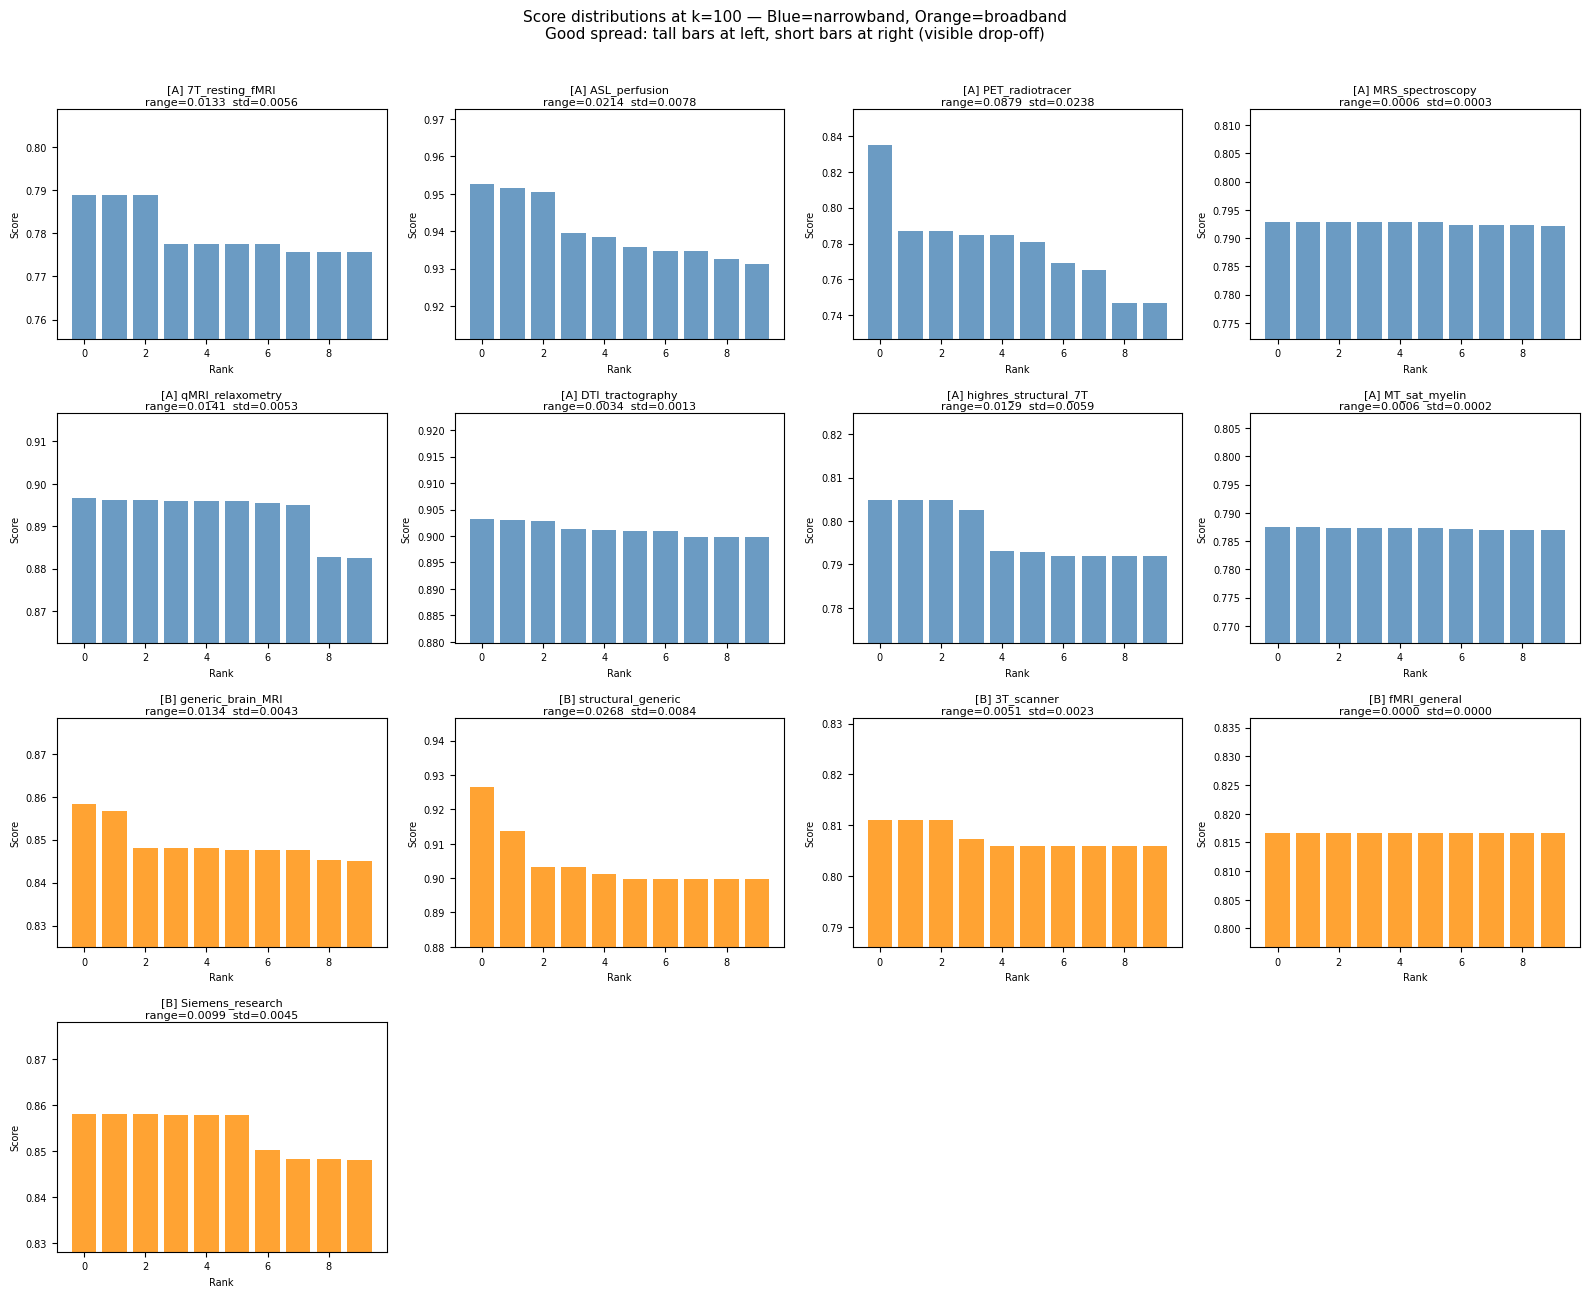

In [27]:
# ── Score distribution histograms for all probe queries ─────────────────────
# Each subplot shows the k=100 cosine-score distribution.
# Narrowband queries should show a heavy left tail (many low-scoring docs);
# broadband queries will be right-skewed (everything scores high = no spread).

n_queries = len(PROBE_QUERIES)
n_cols = 4
n_rows = (n_queries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 3.2), squeeze=False)
axes_flat = axes.flatten()

for idx, (qk, qdata) in enumerate(probe_results.items()):
    ax = axes_flat[idx]
    hit_scores = sorted([h["_score"] for h in qdata["hits"]], reverse=True)
    cat = "A" if qk.startswith("A") else "B"
    color = "steelblue" if cat == "A" else "darkorange"
    ax.bar(range(len(hit_scores)), hit_scores, color=color, alpha=0.8)
    ax.set_ylim(
        max(0, min(hit_scores) - 0.02),
        min(1.0, max(hit_scores) + 0.02)
    )
    spread = qdata["stats"].get("range", 0)
    std = qdata["stats"].get("std",   0)
    ax.set_title(f"[{cat}] {qk[3:]}\n"
                 f"range={spread:.4f}  std={std:.4f}",
                 fontsize=8, pad=3)
    ax.set_xlabel("Rank", fontsize=7)
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for i in range(len(PROBE_QUERIES), len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle(
    f"Score distributions at k={K_SPREAD} — Blue=narrowband, Orange=broadband\n"
    "Good spread: tall bars at left, short bars at right (visible drop-off)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

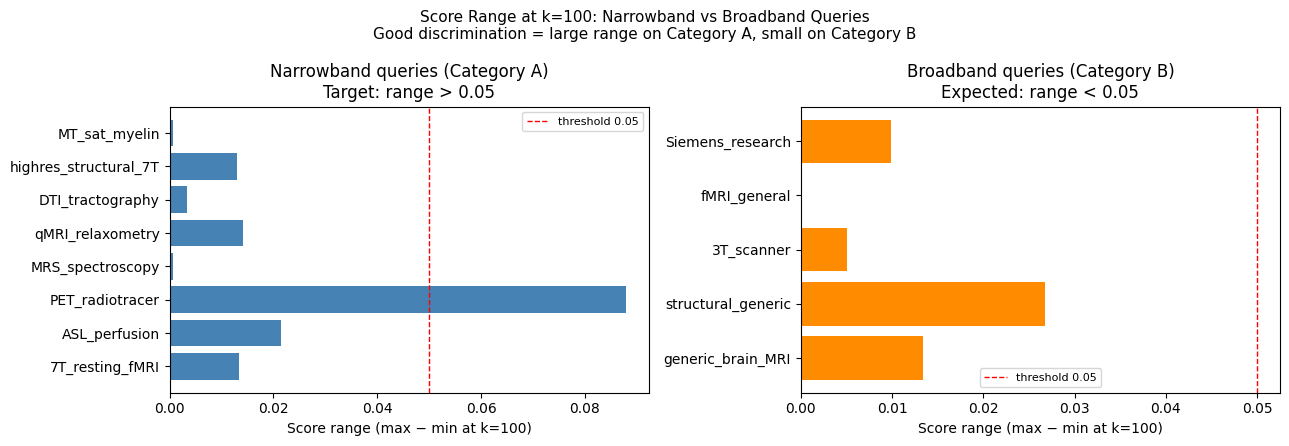


Best-spread narrowband query  : A3_PET_radiotracer  (range=0.0879)
Worst-spread narrowband query : A4_MRS_spectroscopy (range=0.0006)

If narrowband ranges are < 0.02, the encoder is not discriminating these modalities
from the general fMRI/structural bulk — a known weakness of all-mpnet-base-v2 on


In [28]:
# ── Spread comparison bar chart: A vs B categories ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

a_labels = [k[3:] for k in spread_df.index if k.startswith("A")]
a_ranges = [spread_df.loc[k, "range"]
            for k in spread_df.index if k.startswith("A")]
b_labels = [k[3:] for k in spread_df.index if k.startswith("B")]
b_ranges = [spread_df.loc[k, "range"]
            for k in spread_df.index if k.startswith("B")]

ax1.barh(a_labels, a_ranges, color="steelblue")
ax1.set_xlabel("Score range (max − min at k=100)")
ax1.set_title("Narrowband queries (Category A)\nTarget: range > 0.05")
ax1.axvline(0.05, color="red", linestyle="--",
            linewidth=1, label="threshold 0.05")
ax1.legend(fontsize=8)

ax2.barh(b_labels, b_ranges, color="darkorange")
ax2.set_xlabel("Score range (max − min at k=100)")
ax2.set_title("Broadband queries (Category B)\nExpected: range < 0.05")
ax2.axvline(0.05, color="red", linestyle="--",
            linewidth=1, label="threshold 0.05")
ax2.legend(fontsize=8)

plt.suptitle("Score Range at k=100: Narrowband vs Broadband Queries\n"
             "Good discrimination = large range on Category A, small on Category B",
             fontsize=11)
plt.tight_layout()
plt.show()

# Summary
best_a = spread_df[spread_df["category"] == "A-narrowband"]["range"].idxmax()
worst_a = spread_df[spread_df["category"] == "A-narrowband"]["range"].idxmin()
print(
    f"\nBest-spread narrowband query  : {best_a}  (range={spread_df.loc[best_a, 'range']:.4f})")
print(
    f"Worst-spread narrowband query : {worst_a} (range={spread_df.loc[worst_a, 'range']:.4f})")
print(f"\nIf narrowband ranges are < 0.02, the encoder is not discriminating these modalities")
print("from the general fMRI/structural bulk — a known weakness of all-mpnet-base-v2 on")

In [29]:
# ── Top-10 results for the best-spread and worst-spread queries ─────────────
# Examine WHAT the best query retrieved to understand WHY it scored well.

print("=" * 90)
print(f"BEST SPREAD QUERY: {best_a}")
print(f"  Text: {probe_results[best_a]['text']}")
print(f"  Stats: {probe_results[best_a]['stats']}")
print()
df_best = show_hits(probe_results[best_a]["hits"],
                    fields=["dataset", "suffix", "modality_group",
                            "MagneticFieldStrength", "Manufacturer", "description_text"])
display(df_best)

print("=" * 90)
print(f"\nWORST SPREAD QUERY: {worst_a}")
print(f"  Text: {probe_results[worst_a]['text']}")
print(f"  Stats: {probe_results[worst_a]['stats']}")
print()
df_worst = show_hits(probe_results[worst_a]["hits"],
                     fields=["dataset", "suffix", "modality_group",
                             "MagneticFieldStrength", "Manufacturer", "description_text"])
display(df_worst)

print("\nInterpretation: if the worst-spread query also retrieves docs from un-related")
print("modalities (e.g., a structural T1w for an ASL query), the embedding space has")
print("collapsed those modalities into the same neighbourhood — confirming the missing-")
print("field problem found in Section 2B.")

BEST SPREAD QUERY: A3_PET_radiotracer
  Text: PET positron emission tomography radiotracer FDG glucose metabolism brain
  Stats: {'k': 10, 'max': 0.835, 'min': 0.747, 'range': 0.0879, 'std': 0.0238, 'p50': 0.7828, 'p25': 0.766, 'top3_gap': 0.0478}



,_score,dataset,suffix,modality_group,MagneticFieldStrength,Manufacturer,description_text
0,0.8350,pet006,pet,pet,NaN,GE MEDICAL SYSTEMS,A positron emission tomography (PET) scan usin...
1,0.7871,pet002,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
2,0.7871,pet002,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
3,0.7849,pet002,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
4,0.7849,pet002,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
5,0.7806,pet003,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
6,0.7690,pet005,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
7,0.7650,pet001,pet,pet,NaN,Siemens,A positron emission tomography (PET) scan usin...
8,0.7470,ieeg_visual_multimodal,bold,functional,3.0,Siemens,A BOLD functional MRI Blood Oxygen Level Depen...
9,0.7470,ieeg_visual_multimodal,bold,functional,3.0,Siemens,A BOLD functional MRI Blood Oxygen Level Depen...



WORST SPREAD QUERY: A4_MRS_spectroscopy
  Text: in-vivo MR spectroscopy GABA glutamate metabolite single-voxel SVS water suppression
  Stats: {'k': 10, 'max': 0.7928, 'min': 0.7922, 'range': 0.0006, 'std': 0.0003, 'p50': 0.7928, 'p25': 0.7923, 'top3_gap': 0.0}



,_score,dataset,suffix,modality_group,MagneticFieldStrength,Manufacturer,description_text
0,0.7928,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
1,0.7928,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
2,0.7928,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
3,0.7928,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
4,0.7928,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
5,0.7928,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
6,0.7923,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
7,0.7923,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
8,0.7923,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...
9,0.7922,mrs_biggaba,svs,spectroscopy,3.0,Philips,A single-voxel MR spectroscopy MRS scan of the...



Interpretation: if the worst-spread query also retrieves docs from un-related
modalities (e.g., a structural T1w for an ASL query), the embedding space has
collapsed those modalities into the same neighbourhood — confirming the missing-
field problem found in Section 2B.


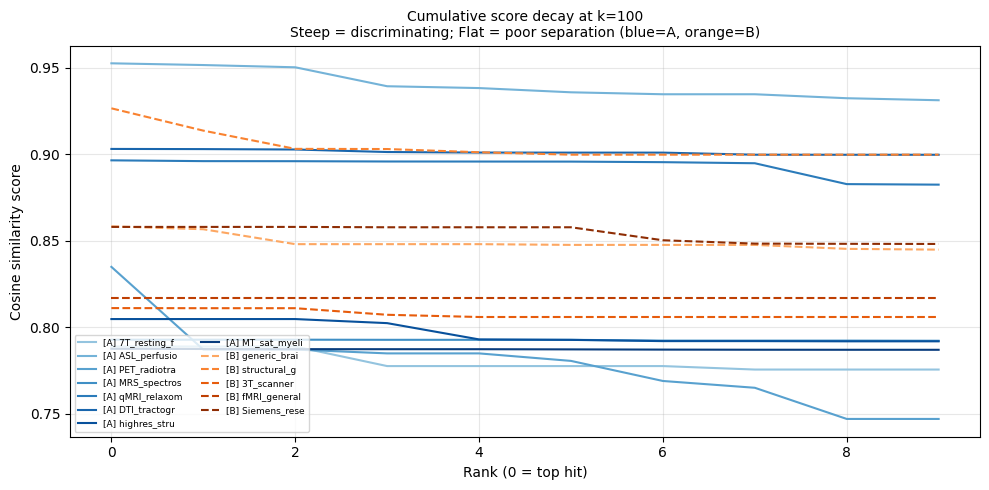

In [30]:
# ── Cumulative score curves for all probes ─────────────────────────────────
# A steep drop-off → good discrimination.
# A flat line → encoder cannot rank relevant above irrelevant.

fig, ax = plt.subplots(figsize=(10, 5))
colors_a = plt.cm.Blues(np.linspace(0.4, 0.95, sum(
    1 for k in PROBE_QUERIES if k.startswith("A"))))
colors_b = plt.cm.Oranges(np.linspace(0.4, 0.95, sum(
    1 for k in PROBE_QUERIES if k.startswith("B"))))
ci_a, ci_b = 0, 0

for qk, qdata in probe_results.items():
    scores = sorted([h["_score"] for h in qdata["hits"]], reverse=True)
    is_a = qk.startswith("A")
    color = colors_a[ci_a] if is_a else colors_b[ci_b]
    ls = "-" if is_a else "--"
    if is_a:
        ci_a += 1
    else:
        ci_b += 1
    ax.plot(range(len(scores)), scores, color=color, linestyle=ls,
            linewidth=1.5, label=f"{'[A]' if is_a else '[B]'} {qk[3:15]}")

ax.set_xlabel("Rank (0 = top hit)")
ax.set_ylabel("Cosine similarity score")
ax.set_title(f"Cumulative score decay at k={K_SPREAD}\n"
             "Steep = discriminating; Flat = poor separation (blue=A, orange=B)",
             fontsize=10)
ax.legend(fontsize=6.5, ncol=2, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ── Modality purity of top-10 hits per probe query ─────────────────────────
# Good discrimination → all top-10 hits match the expected modality group.
# Poor discrimination → top-10 hits are a mix of unrelated modalities.

EXPECTED_MODALITY = {
    "A1_7T_resting_fMRI":     "functional",
    "A2_ASL_perfusion":       "perfusion",
    "A3_PET_radiotracer":     "pet",
    "A4_MRS_spectroscopy":    "spectroscopy",
    "A5_qMRI_relaxometry":    "quantitative",
    "A6_DTI_tractography":    "diffusion",
    "A7_highres_structural_7T": "structural",
    "A8_MT_sat_myelin":       "quantitative",
}

purity_rows = []
for qk, qdata in probe_results.items():
    if qk not in EXPECTED_MODALITY:
        continue
    expected = EXPECTED_MODALITY[qk]
    top10 = qdata["hits"][:10]
    hits_mg = [h["_source"].get("modality_group", "?") for h in top10]
    purity = round(100 * hits_mg.count(expected) /
                   len(hits_mg)) if top10 else 0
    purity_rows.append({
        "query_key":       qk,
        "expected_group":  expected,
        "top10_purity_%":  purity,
        "top10_groups":    ", ".join(sorted(set(hits_mg))),
        "range":           qdata["stats"].get("range", 0),
    })

purity_df = pd.DataFrame(purity_rows).set_index("query_key")
print("Top-10 modality purity per narrowband query:")
display(purity_df.sort_values("top10_purity_%", ascending=False))
print("\n100% = all top-10 hits are the intended modality → embedding space is clean")
print("< 50% = the encoder cannot reliably distinguish the target modality")

Top-10 modality purity per narrowband query:


,expected_group,top10_purity_%,top10_groups,range
query_key,,,,
A1_7T_resting_fMRI,functional,100,functional,0.0133
A2_ASL_perfusion,perfusion,100,perfusion,0.0214
A4_MRS_spectroscopy,spectroscopy,100,spectroscopy,0.0006
A5_qMRI_relaxometry,quantitative,100,quantitative,0.0141
A7_highres_structural_7T,structural,100,structural,0.0129
A6_DTI_tractography,diffusion,100,diffusion,0.0034
A8_MT_sat_myelin,quantitative,100,quantitative,0.0006
A3_PET_radiotracer,pet,80,"functional, pet",0.0879



100% = all top-10 hits are the intended modality → embedding space is clean
< 50% = the encoder cannot reliably distinguish the target modality


---
## Section 4 — Document Count Gap: Filesystem vs PyBIDS vs Elasticsearch

For each indexed dataset and subject we compare **three independent file counts** to
identify exactly where NIfTI files disappear before reaching the search index:

| Source | Description |
|--------|-------------|
| **Filesystem (FS)** | All `.nii.gz` **and** `.nii` files found directly on disk under each dataset directory |
| **PyBIDS** | Files returned by `BIDSLayout.get(extension=[".nii.gz", ".nii"])` with `validate=False` |
| **Elasticsearch** | Documents indexed in `neuroimaging` |

### Gap layers and their root causes

| Gap | Column | Meaning | Likely cause |
|-----|--------|---------|-------------|
| **FS → PyBIDS** | `gap_fs_bids` | .nii.gz on disk that BIDS doesn't recognise | Non-standard filename; file not in a `sub-*/` folder |
| **PyBIDS → ES** | `gap_bids_es` | Files BIDS sees but ingest didn't index | Suffix filtering (hypothesis); ingest crash |
| **FS → ES** | `gap_fs_es` | Total end-to-end loss (.nii.gz only) | Combination of both |

Additionally, **uncompressed `.nii` files** on the filesystem are invisible to the
ingest pipeline because `generate_documents()` calls `layout.get(extension=".nii.gz")`.

> Config knob: `TOP_N_GAP_DATASETS` (default 8) controls how many datasets
> appear in the per-subject breakdown chart (§ S4.6).


In [ ]:
# ── S4.1 Collect ES document counts per (dataset, subject, suffix) ────────
# Single composite-aggregation: 3 levels → dataset → subject → suffix.

es_counts: dict = {}         # {dataset: {subject: {suffix: int}}}
es_suffix_total: dict = {}   # {dataset: {suffix: total_across_subjects}}

resp_agg = client.search(
    index=INDEX_NAME, size=0,
    aggs={
        "by_dataset": {
            "terms": {"field": "dataset", "size": 500},
            "aggs": {
                "by_subject": {
                    "terms": {"field": "subject", "size": 500},
                    "aggs": {
                        "by_suffix": {
                            "terms": {"field": "suffix", "size": 200}
                        }
                    }
                }
            }
        }
    }
)

for ds_bucket in resp_agg["aggregations"]["by_dataset"]["buckets"]:
    ds = ds_bucket["key"]
    es_counts[ds] = {}
    es_suffix_total[ds] = {}
    for sub_bucket in ds_bucket["by_subject"]["buckets"]:
        sub = sub_bucket["key"]
        es_counts[ds][sub] = {}
        for sfx_bucket in sub_bucket["by_suffix"]["buckets"]:
            sfx = sfx_bucket["key"]
            cnt = sfx_bucket["doc_count"]
            es_counts[ds][sub][sfx] = cnt
            es_suffix_total[ds][sfx] = es_suffix_total[ds].get(sfx, 0) + cnt

total_es_docs = sum(
    cnt
    for sub_dict in es_counts.values()
    for sfx_dict in sub_dict.values()
    for cnt in sfx_dict.values()
)
print(f"ES: {len(es_counts)} datasets, {total_es_docs:,} total documents")

ES: 76 datasets, 4,423 total documents


In [ ]:
# ── S4.2 Collect filesystem NIfTI counts per (dataset, subject, suffix) ──
# Scan both .nii.gz and .nii files.  Subject is inferred from the first
# 'sub-XX' path component under the dataset root.  Suffix is the last
# underscore-delimited token in the basename before the extension.

import re as _re

_BIDS_EXT = _re.compile(r"(.*?)(\.nii\.gz|\.nii)$")


def _parse_bids_filename(name: str):
    """Return (base, ext) where ext is '.nii.gz' or '.nii', else (None, None)."""
    m = _BIDS_EXT.match(name)
    return (m.group(1), m.group(2)) if m else (None, None)


def _extract_suffix(base: str) -> str:
    """Last '_'-separated token from a BIDS filename base."""
    return base.split("_")[-1] if "_" in base else base


def _extract_subject(path: Path, dataset_root: Path) -> str:
    """First 'sub-XX' component in the path relative to dataset_root."""
    try:
        rel_parts = path.relative_to(dataset_root).parts
    except ValueError:
        rel_parts = path.parts
    for part in rel_parts:
        if part.startswith("sub-"):
            return part[4:]   # strip 'sub-' to match ES subject field
    return "__no_subject__"


fs_counts: dict = {}      # {dataset: {subject: {suffix: {"nii_gz": n, "nii": n}}}}
fs_ext_gap: dict = {}     # {dataset: {suffix: {"nii_gz": n, "nii": n}}}

for ds_name in INDEXED_DATASETS:
    ds_path = DATA_DIR / ds_name
    if not ds_path.exists():
        continue
    fs_counts[ds_name] = {}
    fs_ext_gap[ds_name] = {}
    for p in ds_path.rglob("*"):
        if not p.is_file():
            continue
        base, ext = _parse_bids_filename(p.name)
        if base is None:
            continue
        suffix = _extract_suffix(base)
        subject = _extract_subject(p, ds_path)
        ext_key = "nii_gz" if ext == ".nii.gz" else "nii"
        fs_counts[ds_name].setdefault(subject, {}).setdefault(
            suffix, {"nii_gz": 0, "nii": 0}
        )[ext_key] += 1
        fs_ext_gap[ds_name].setdefault(
            suffix, {"nii_gz": 0, "nii": 0})[ext_key] += 1

# 4-level iteration: dataset → subject → suffix → ext_dict
total_fs_gz = sum(
    ext_d["nii_gz"]
    for ds_d in fs_counts.values()
    for sub_d in ds_d.values()
    for ext_d in sub_d.values()
)
total_fs_nii = sum(
    ext_d["nii"]
    for ds_d in fs_counts.values()
    for sub_d in ds_d.values()
    for ext_d in sub_d.values()
)
print(f"Filesystem: {len(fs_counts)} datasets")
print(f"  .nii.gz files : {total_fs_gz:,}")
print(
    f"  .nii files    : {total_fs_nii:,}  ← these are NEVER indexed (ingest only queries .nii.gz)")
print(f"  Total NIfTIs  : {total_fs_gz + total_fs_nii:,}")

Filesystem: 76 datasets
  .nii.gz files : 4,451
  .nii files    : 72  ← these are NEVER indexed (ingest only queries .nii.gz)
  Total NIfTIs  : 4,523


In [ ]:
# ── S4.3 Collect PyBIDS counts per (dataset, subject, suffix) ────────────
# Run BIDSLayout for every indexed dataset, querying BOTH .nii.gz and .nii so
# we can see PyBIDS recognition rate independent of extension filtering.
#
# ~1–3 min for all datasets; BIDSLayout is the bottleneck.

from bids import BIDSLayout

bids_counts: dict = {}      # {dataset: {subject: {suffix: {"nii_gz": n, "nii": n}}}}
bids_unrecognised: dict = {}  # {dataset: int} — .nii.gz files on disk NOT in layout

print(f"Running BIDSLayout for {len(INDEXED_DATASETS)} datasets …")
for ds_name in tqdm(INDEXED_DATASETS, desc="BIDSLayout scan"):
    ds_path = DATA_DIR / ds_name
    if not ds_path.exists():
        continue
    try:
        layout = BIDSLayout(str(ds_path), validate=False)
    except Exception as exc:
        print(f"  [{ds_name}] BIDSLayout failed: {exc}")
        continue

    bids_counts[ds_name] = {}
    for ext, ext_key in [(".nii.gz", "nii_gz"), (".nii", "nii")]:
        for bf in layout.get(extension=ext):
            entities = bf.entities
            sub = str(entities.get("subject", "__no_subject__"))
            sfx = str(entities.get("suffix", "__no_suffix__"))
            bids_counts[ds_name].setdefault(sub, {}).setdefault(
                sfx, {"nii_gz": 0, "nii": 0}
            )
            bids_counts[ds_name][sub][sfx][ext_key] += 1

    # How many .nii.gz files did PyBIDS miss for this dataset?
    # fs_counts[ds_name] = {subject: {suffix: {"nii_gz": n, "nii": n}}}
    fs_nii_gz_total = sum(
        ext_d["nii_gz"]
        for sub_d in fs_counts.get(ds_name, {}).values()
        for ext_d in sub_d.values()
    )
    bids_nii_gz_total = sum(
        ext_d["nii_gz"]
        for sub_d in bids_counts[ds_name].values()
        for ext_d in sub_d.values()
    )
    bids_unrecognised[ds_name] = fs_nii_gz_total - bids_nii_gz_total

# 4-level iteration: dataset → subject → suffix → ext_dict
total_bids_nii_gz = sum(
    ext_d["nii_gz"]
    for ds_d in bids_counts.values()
    for sub_d in ds_d.values()
    for ext_d in sub_d.values()
)
total_bids_nii = sum(
    ext_d["nii"]
    for ds_d in bids_counts.values()
    for sub_d in ds_d.values()
    for ext_d in sub_d.values()
)
total_unrecognised = sum(max(0, v) for v in bids_unrecognised.values())
print(f"\nPyBIDS: {len(bids_counts)} datasets")
print(f"  .nii.gz recognised   : {total_bids_nii_gz:,}")
print(f"  .nii    recognised   : {total_bids_nii:,}")
print(f"  .nii.gz unrecognised (FS − BIDS): {total_unrecognised:,}")

Running BIDSLayout for 76 datasets …


BIDSLayout scan:   0%|          | 0/76 [00:00<?, ?it/s]


PyBIDS: 76 datasets
  .nii.gz recognised   : 4,423
  .nii    recognised   : 59
  .nii.gz unrecognised (FS − BIDS): 28


In [ ]:
# ── S4.4 Assemble combined comparison DataFrame ───────────────────────────
# Rows: one per (dataset, subject).  Columns: n_fs_gz, n_fs_nii, n_bids_gz,
# n_bids_nii, n_es, and the three gap columns.

all_datasets = sorted(
    set(fs_counts) | set(bids_counts) | set(es_counts)
)
all_subjects_per_ds: dict = {}
for ds in all_datasets:
    subs = (
        set(fs_counts.get(ds, {}))
        | set(bids_counts.get(ds, {}))
        | set(es_counts.get(ds, {}))
    ) - {"__no_subject__"}
    all_subjects_per_ds[ds] = subs

rows_cov = []
for ds in all_datasets:
    for sub in sorted(all_subjects_per_ds[ds]):
        n_fs_gz = sum(d["nii_gz"]
                      for d in fs_counts.get(ds,    {}).get(sub, {}).values())
        n_fs_nii = sum(d["nii"]
                       for d in fs_counts.get(ds,    {}).get(sub, {}).values())
        n_bids_gz = sum(d["nii_gz"]
                        for d in bids_counts.get(ds, {}).get(sub, {}).values())
        n_bids_nii = sum(d["nii"]
                         for d in bids_counts.get(ds, {}).get(sub, {}).values())
        n_es = sum(es_counts.get(ds, {}).get(sub, {}).values())

        rows_cov.append({
            "dataset":     ds,
            "subject":     sub,
            "n_fs_gz":     n_fs_gz,     # .nii.gz on disk
            "n_fs_nii":    n_fs_nii,    # .nii on disk (never indexed)
            "n_bids_gz":   n_bids_gz,   # .nii.gz PyBIDS recognises
            "n_bids_nii":  n_bids_nii,  # .nii PyBIDS recognises
            "n_es":        n_es,        # ES documents
            "gap_fs_bids": n_fs_gz - n_bids_gz,   # > 0 → PyBIDS missed some .nii.gz
            "gap_bids_es": n_bids_gz - n_es,       # > 0 → ingest missed some BIDS files
            "gap_fs_es":   n_fs_gz - n_es,         # > 0 → total end-to-end loss
        })

coverage_df = pd.DataFrame(rows_cov)
print(
    f"Coverage DataFrame: {len(coverage_df):,} rows  ({coverage_df['dataset'].nunique()} datasets)")

ds_summary = (
    coverage_df
    .groupby("dataset")[["n_fs_gz", "n_fs_nii", "n_bids_gz", "n_es",
                         "gap_fs_bids", "gap_bids_es", "gap_fs_es"]]
    .sum()
    .sort_values("gap_fs_es", ascending=False)
)
ds_summary["pct_indexed"] = (
    100 * ds_summary["n_es"] / ds_summary["n_fs_gz"].replace(0, np.nan)
).round(1)
print("\nDataset-level summary (sorted by FS→ES gap, descending):")
display(ds_summary.head(20))

Coverage DataFrame: 591 rows  (76 datasets)

Dataset-level summary (sorted by FS→ES gap, descending):


,n_fs_gz,n_fs_nii,n_bids_gz,n_es,gap_fs_bids,gap_bids_es,gap_fs_es,pct_indexed
dataset,,,,,,,,
qmri_mtsat,10,0,5,5,5,0,5,50.0
ds000248,6,9,2,2,4,0,4,33.3
qmri_vfa,7,0,4,4,3,0,3,57.1
qmri_mese,35,0,32,32,3,0,3,91.4
qmri_irt1,6,0,4,4,2,0,2,66.7
ieeg_epilepsy,3,0,2,2,1,0,1,66.7
qmri_sa2rage,3,0,2,2,1,0,1,66.7
ieeg_epilepsyNWB,3,0,2,2,1,0,1,66.7
2d_mb_pcasl,4,0,4,4,0,0,0,100.0


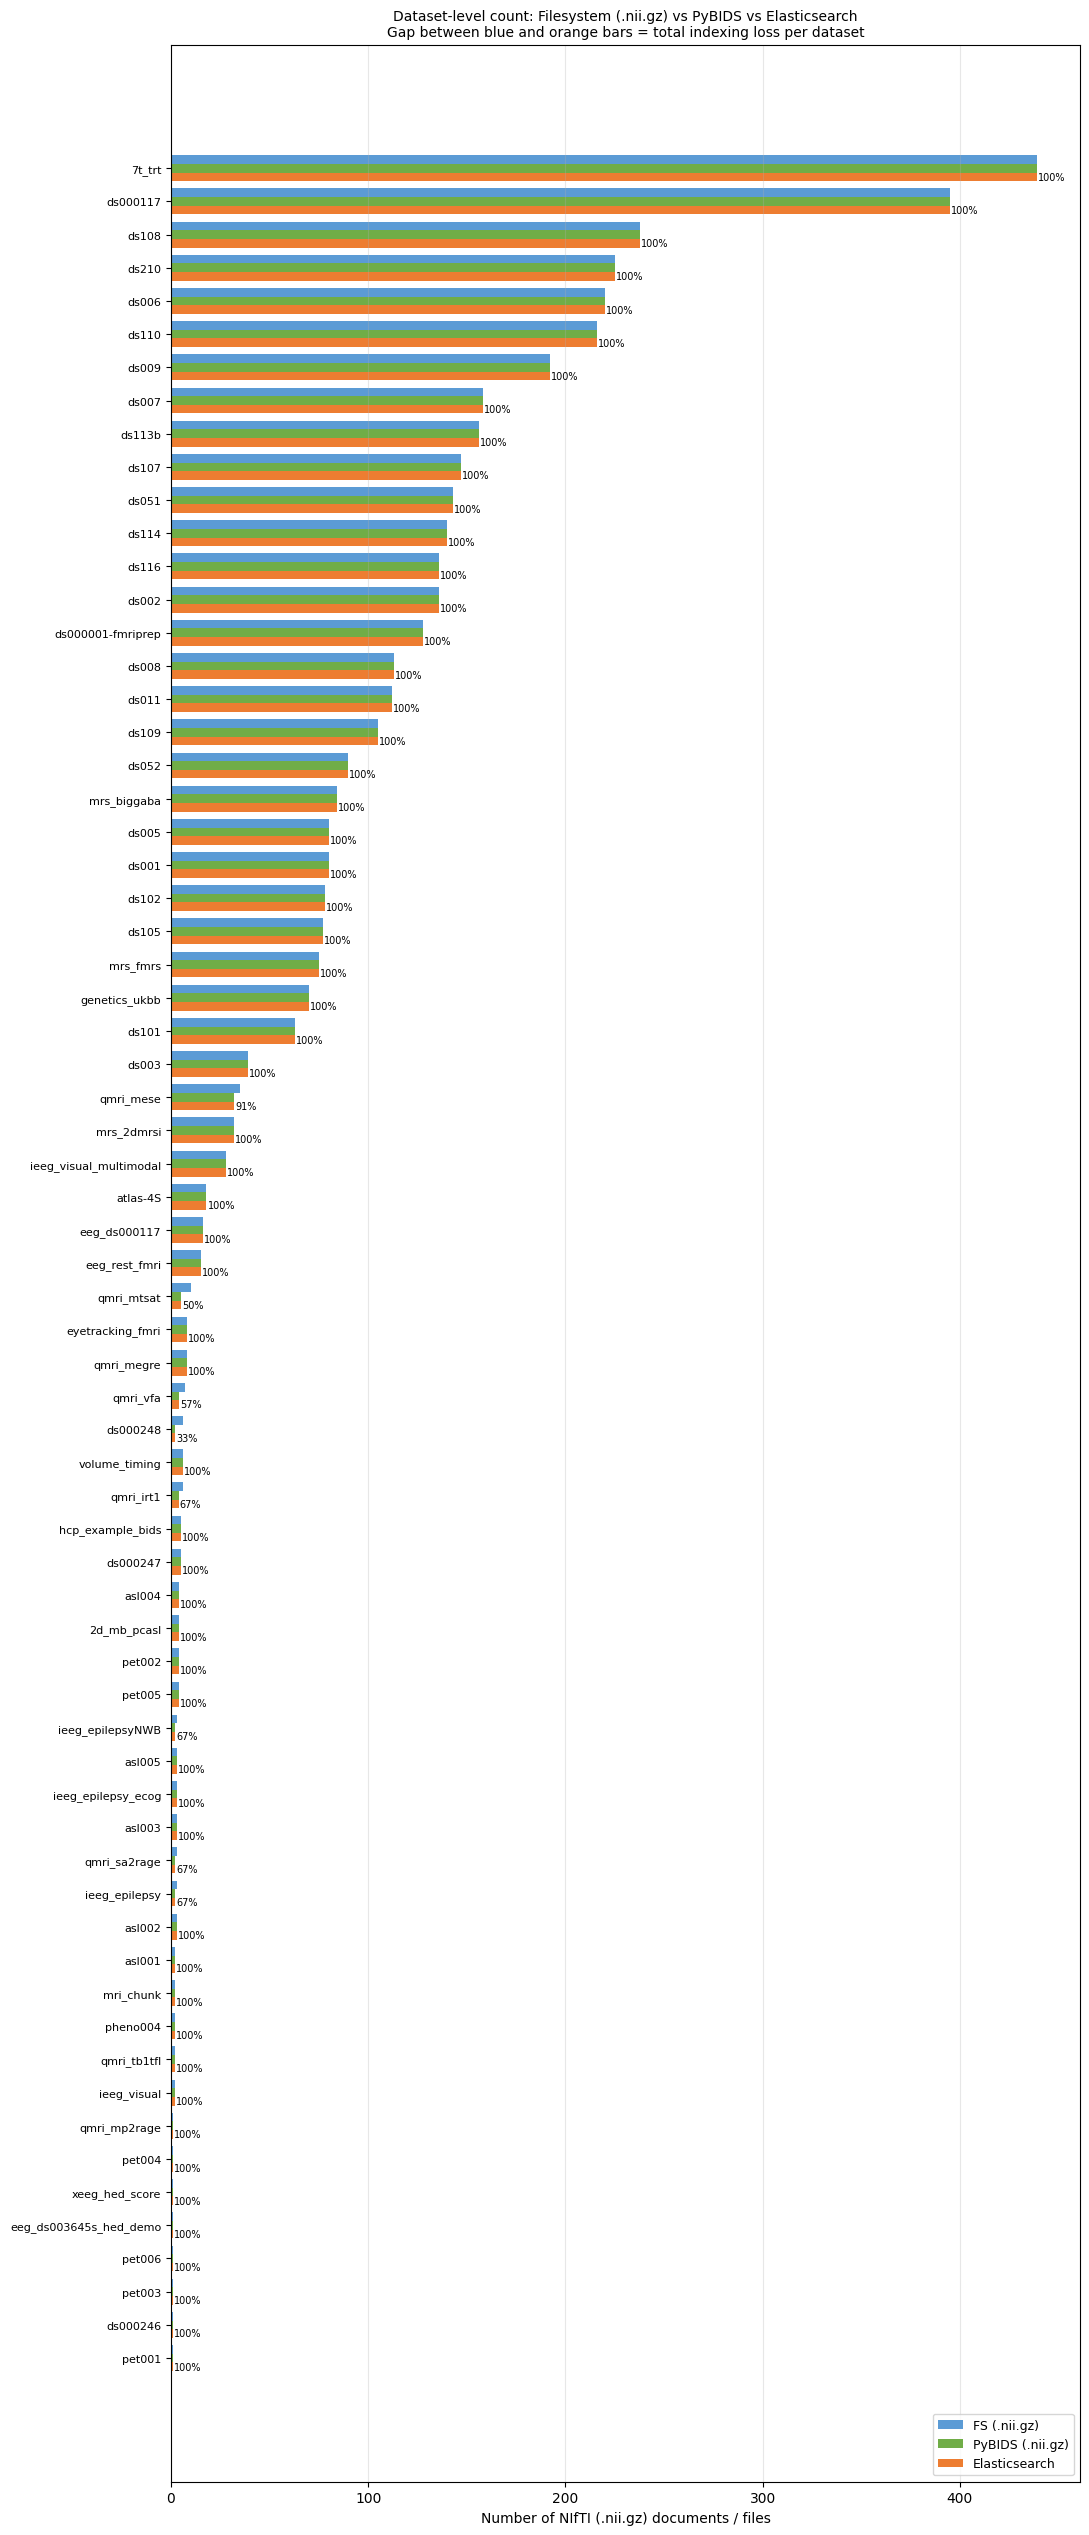


Datasets containing uncompressed .nii files (NEVER indexed):


,n_fs_nii,n_fs_gz
dataset,,
ds000117,47,395
ds000248,9,6
qmri_mp2rage,8,1
pet002,4,4
pet001,1,1
pet003,1,1


In [ ]:
# ── S4.5 Dataset-level grouped bar chart ────────────────────────────────────
# Compare total .nii.gz (FS) vs PyBIDS-recognised vs ES-indexed per dataset.
# Only shows datasets with at least one NIfTI file on disk.

plot_ds = ds_summary[ds_summary["n_fs_gz"] >
                     0].sort_values("n_fs_gz", ascending=True)
if plot_ds.empty:
    print("No datasets to plot.")
else:
    bar_h = max(5, len(plot_ds) * 0.38)
    fig, ax = plt.subplots(figsize=(11, bar_h))
    y = np.arange(len(plot_ds))
    h = 0.26

    ax.barh(y + h,  plot_ds["n_fs_gz"],   height=h,
            color="#5b9bd5", label="FS (.nii.gz)")
    ax.barh(y,      plot_ds["n_bids_gz"],  height=h,
            color="#70ad47", label="PyBIDS (.nii.gz)")
    ax.barh(y - h,  plot_ds["n_es"],       height=h,
            color="#ed7d31", label="Elasticsearch")

    ax.set_yticks(y)
    ax.set_yticklabels(plot_ds.index, fontsize=8)
    ax.set_xlabel("Number of NIfTI (.nii.gz) documents / files")
    ax.set_title(
        "Dataset-level count: Filesystem (.nii.gz) vs PyBIDS vs Elasticsearch\n"
        "Gap between blue and orange bars = total indexing loss per dataset",
        fontsize=10,
    )
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.3)

    # Annotate pct_indexed on each ES bar
    for i, (ds_name, row) in enumerate(plot_ds.iterrows()):
        pct = row["pct_indexed"]
        if not np.isnan(pct):
            ax.text(
                row["n_es"] + 0.5, i - h,
                f"{pct:.0f}%", va="center", ha="left", fontsize=7,
            )

    plt.tight_layout()
    plt.show()

    # Surface .nii-only files that are completely invisible
    nii_only_ds = ds_summary[ds_summary["n_fs_nii"]
                             > 0][["n_fs_nii", "n_fs_gz"]]
    if not nii_only_ds.empty:
        print("\nDatasets containing uncompressed .nii files (NEVER indexed):")
        display(nii_only_ds.sort_values("n_fs_nii", ascending=False))
    else:
        print("\nNo uncompressed .nii files found — extension gap is not a factor.")

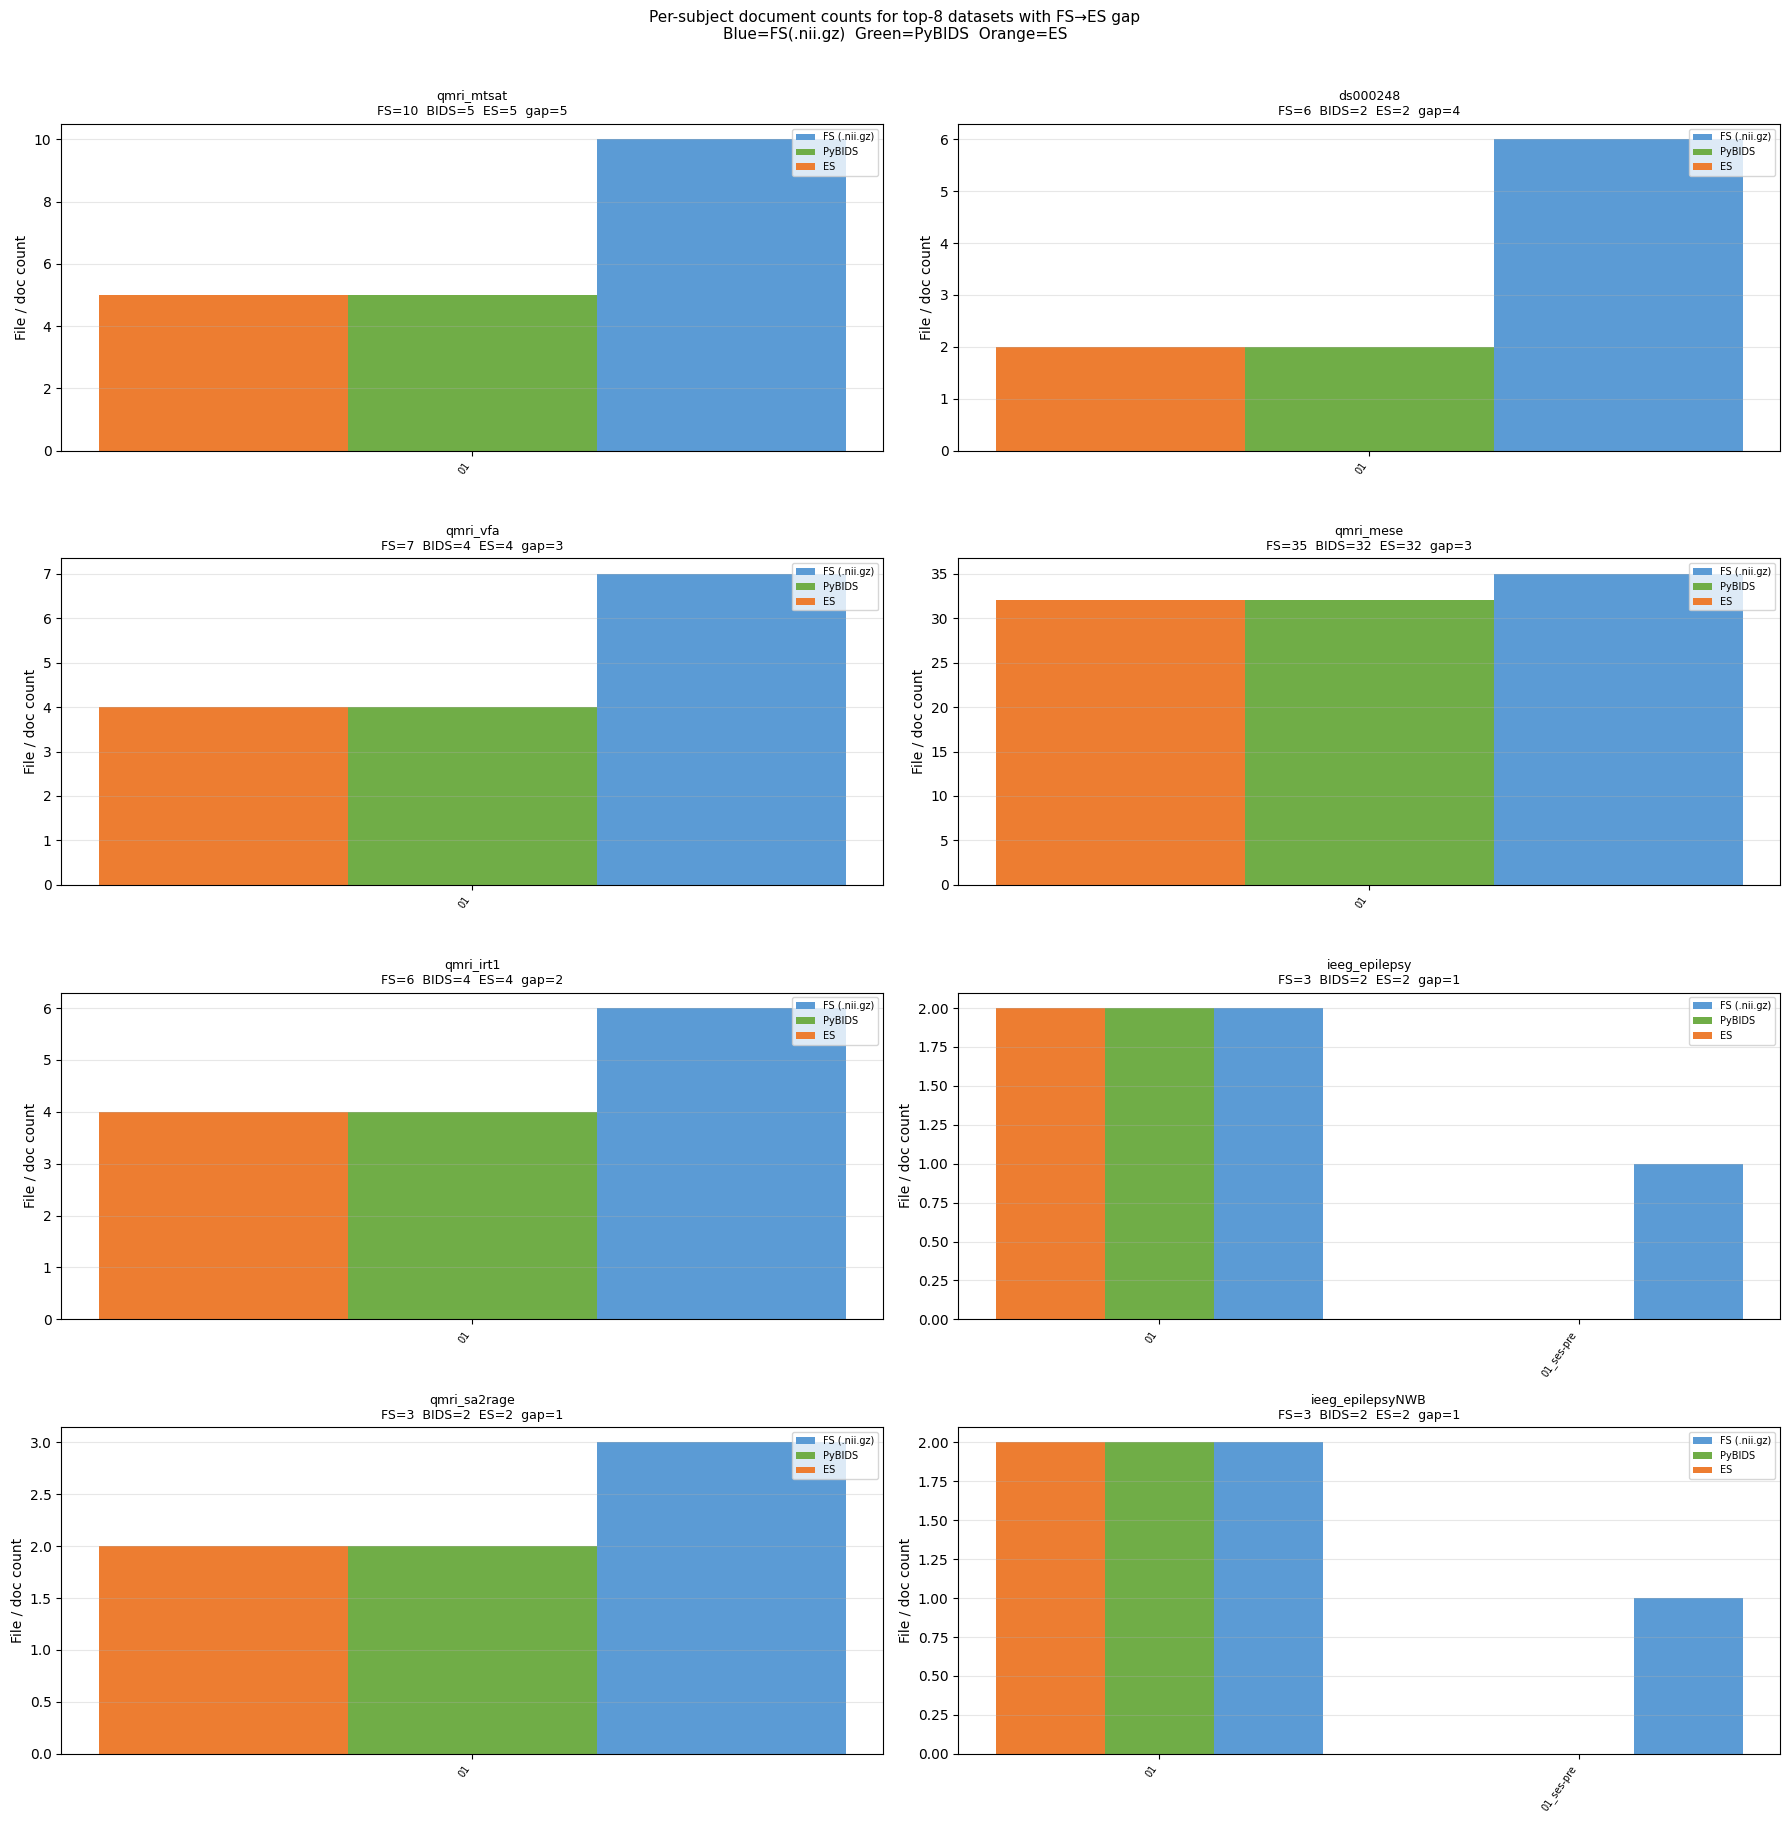

In [ ]:
# ── S4.6 Per-subject subplot grid for the worst-gap datasets ──────────────
# For the TOP_N_GAP_DATASETS with the largest absolute FS→ES gap we show a
# per-subject breakdown.  Subjects are on the x-axis; three bars per subject.

gap_sorted = ds_summary[ds_summary["gap_fs_es"] > 0].sort_values(
    "gap_fs_es", ascending=False
).head(TOP_N_GAP_DATASETS)

if gap_sorted.empty:
    print("No FS→ES gaps found. All .nii.gz files appear fully indexed.")
else:
    n_plots = len(gap_sorted)
    n_cols = min(2, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 9, n_rows * 4.5),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for idx, (ds_name, ds_row) in enumerate(gap_sorted.iterrows()):
        ax = axes_flat[idx]
        sub_df = (
            coverage_df[coverage_df["dataset"] == ds_name]
            .set_index("subject")
            .sort_index()
        )
        if sub_df.empty:
            ax.set_visible(False)
            continue

        x = np.arange(len(sub_df))
        w = 0.26
        ax.bar(x + w,  sub_df["n_fs_gz"],  width=w,
               color="#5b9bd5", label="FS (.nii.gz)")
        ax.bar(x,      sub_df["n_bids_gz"], width=w,
               color="#70ad47", label="PyBIDS")
        ax.bar(x - w,  sub_df["n_es"],      width=w,
               color="#ed7d31", label="ES")

        ax.set_xticks(x)
        ax.set_xticklabels(sub_df.index, rotation=55, ha="right", fontsize=7)
        ax.set_ylabel("File / doc count")
        ax.set_title(
            f"{ds_name}\n"
            f"FS={int(ds_row['n_fs_gz'])}  BIDS={int(ds_row['n_bids_gz'])}"
            f"  ES={int(ds_row['n_es'])}  gap={int(ds_row['gap_fs_es'])}",
            fontsize=9,
        )
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(axis="y", alpha=0.3)

    for i in range(len(gap_sorted), len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle(
        f"Per-subject document counts for top-{len(gap_sorted)} datasets with FS→ES gap\n"
        "Blue=FS(.nii.gz)  Green=PyBIDS  Orange=ES",
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# ── S4.7 Suffix-level gap breakdown ──────────────────────────────────────
# For each suffix, calculate total counts across all datasets at each layer.
# This is the key cell for testing the suffix-filtering hypothesis.
#
# SUFFIX_DESCRIPTIONS and _INGEST_MODALITY_GROUPS are imported from ingest.py
# in cell 13 (Section 1b).  They map suffix → human label / modality group.

from collections import defaultdict as _dd

suffix_fs_gz = _dd(int)   # total .nii.gz files on disk
suffix_fs_nii = _dd(int)   # total .nii files on disk
suffix_bids_gz = _dd(int)   # total .nii.gz files PyBIDS recognises
suffix_es = _dd(int)   # total ES docs

for ds in all_datasets:
    # filesystem: {subject: {suffix: {ext: n}}}
    for sub_d in fs_counts.get(ds, {}).values():
        for sfx, ext_d in sub_d.items():
            suffix_fs_gz[sfx] += ext_d["nii_gz"]
            suffix_fs_nii[sfx] += ext_d["nii"]
    # bids: same shape
    for sub_d in bids_counts.get(ds, {}).values():
        for sfx, ext_d in sub_d.items():
            suffix_bids_gz[sfx] += ext_d["nii_gz"]
    # elasticsearch: {subject: {suffix: count}}
    for sfx_dict in es_counts.get(ds, {}).values():
        for sfx, cnt in sfx_dict.items():
            suffix_es[sfx] += cnt

all_sfx_keys = (
    set(suffix_fs_gz) | set(suffix_fs_nii)
    | set(suffix_bids_gz) | set(suffix_es)
)

# _INGEST_MODALITY_GROUPS is a dict {suffix: modality_group} from ingest.py
_mod_groups_dict = _INGEST_MODALITY_GROUPS if "_INGEST_MODALITY_GROUPS" in dir() else {}

suffix_rows = []
for sfx in sorted(all_sfx_keys):
    n_fs_gz = suffix_fs_gz.get(sfx, 0)
    n_fs_nii = suffix_fs_nii.get(sfx, 0)
    n_bids_gz = suffix_bids_gz.get(sfx, 0)
    n_es_cnt = suffix_es.get(sfx, 0)
    suffix_rows.append({
        "suffix":         sfx,
        "n_fs_gz":        n_fs_gz,
        "n_fs_nii":       n_fs_nii,
        "n_bids_gz":      n_bids_gz,
        "n_es":           n_es_cnt,
        "gap_fs_bids":    n_fs_gz - n_bids_gz,   # PyBIDS missed
        "gap_bids_es":    n_bids_gz - n_es_cnt,  # ingest missed
        "gap_fs_es":      n_fs_gz - n_es_cnt,    # total loss
        "in_SUFFIX_DESC": sfx in SUFFIX_DESCRIPTIONS,
        "in_MOD_GROUPS":  sfx in _mod_groups_dict,
    })

suffix_df = pd.DataFrame(suffix_rows).set_index("suffix")

print("Suffix-level coverage (sorted by FS→ES gap):")
display(
    suffix_df.sort_values("gap_fs_es", ascending=False)
    [["n_fs_gz", "n_bids_gz", "n_es", "gap_fs_bids",
      "gap_bids_es", "gap_fs_es", "in_SUFFIX_DESC", "in_MOD_GROUPS"]]
    .head(30)
)

# Key question: suffixes in BIDS but with gap_bids_es > 0
bids_to_es_gap = suffix_df[suffix_df["gap_bids_es"] > 0]
if bids_to_es_gap.empty:
    print("\n✓ No BIDS→ES suffix gap found: every suffix PyBIDS sees is in Elasticsearch.")
    print("  → The suffix-filtering hypothesis is NOT confirmed by current data.")
else:
    print(f"\n⚠ BIDS→ES gap for {len(bids_to_es_gap)} suffixes:")
    display(bids_to_es_gap[["n_bids_gz", "n_es", "gap_bids_es",
                            "in_SUFFIX_DESC", "in_MOD_GROUPS"]])
    print("  → Suffix filtering IS a factor for the suffixes above.")

Suffix-level coverage (sorted by FS→ES gap):


,n_fs_gz,n_bids_gz,n_es,gap_fs_bids,gap_bids_es,gap_fs_es,in_SUFFIX_DESC,in_MOD_GROUPS
suffix,,,,,,,,
dseg,89,81,81,8,0,8,True,False
register,4,0,0,4,0,4,True,False
M0map,4,0,0,4,0,4,True,False
T1map,25,22,22,3,0,3,True,True
TB1map,3,0,0,3,0,3,True,True
T1w,605,603,603,2,0,2,True,True
MTsat,1,0,0,1,0,1,True,True
MWFmap,1,0,0,1,0,1,True,False
MTRmap,1,0,0,1,0,1,True,True



✓ No BIDS→ES suffix gap found: every suffix PyBIDS sees is in Elasticsearch.
  → The suffix-filtering hypothesis is NOT confirmed by current data.


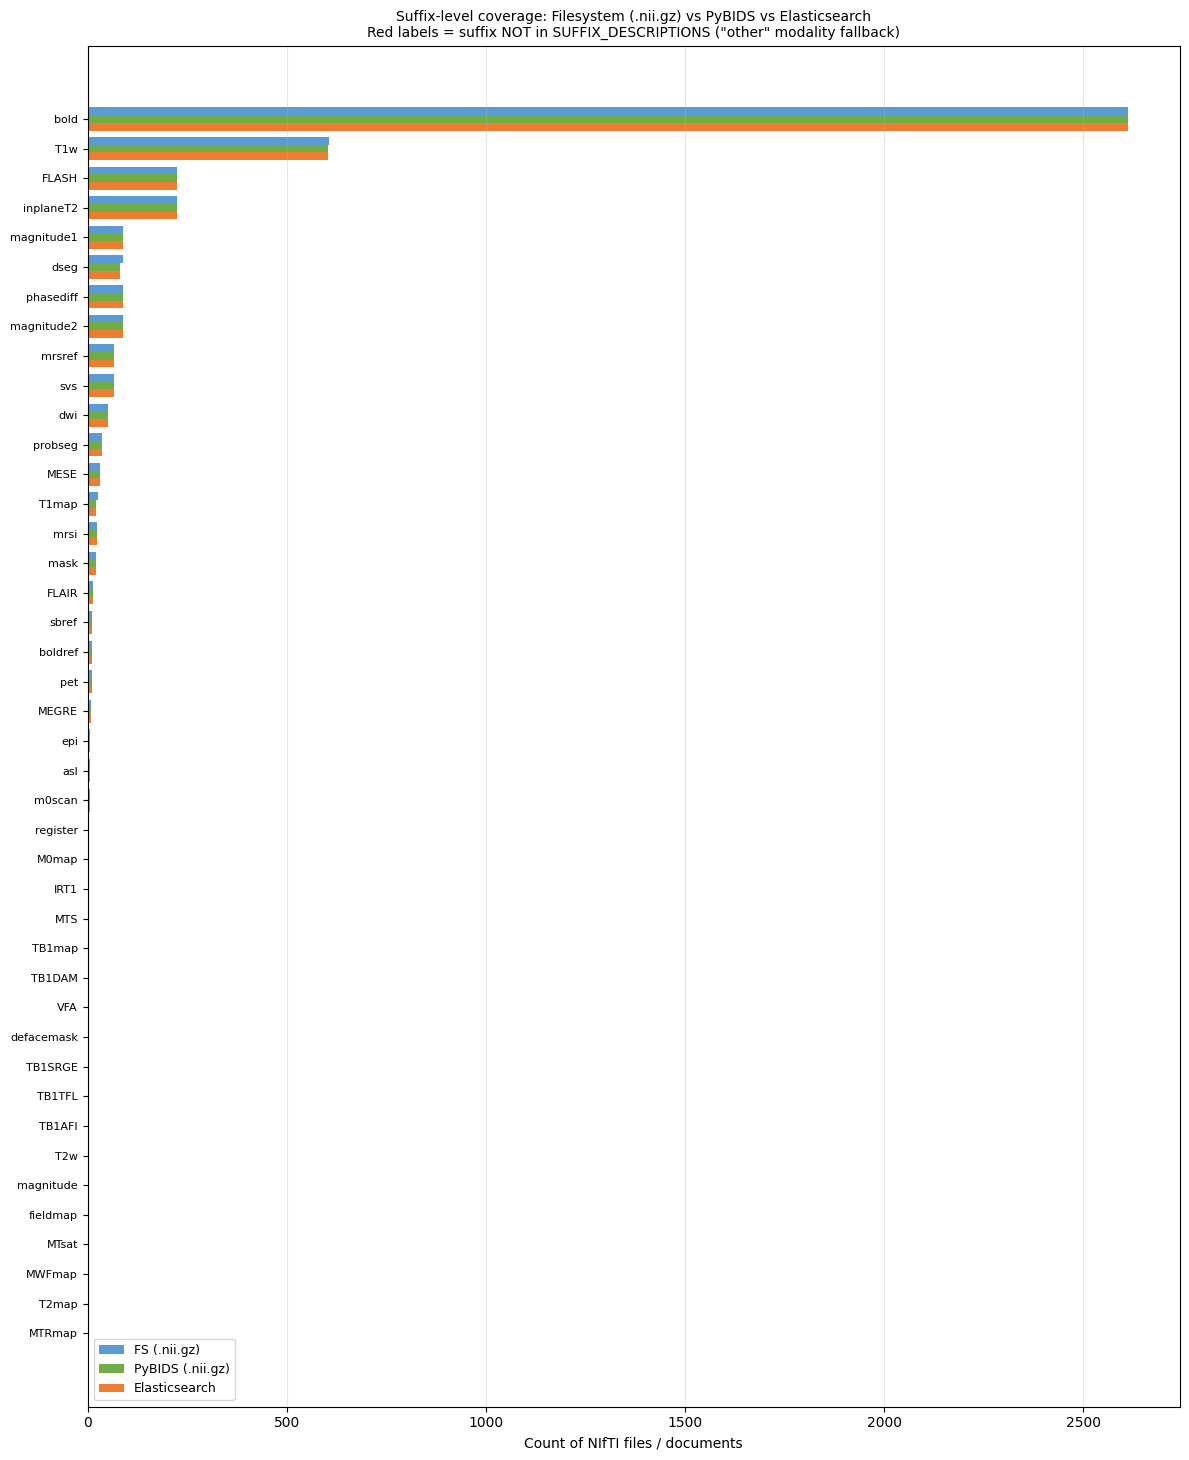

In [ ]:
# ── S4.8 Suffix gap bar chart ─────────────────────────────────────────────
# Three-layer bar chart: FS (.nii.gz) / PyBIDS / ES for each suffix.
# Suffixes absent from SUFFIX_DESCRIPTIONS are highlighted in red.

plot_sfx = suffix_df[suffix_df["n_fs_gz"] >
                     0].sort_values("n_fs_gz", ascending=True)
if plot_sfx.empty:
    print("No suffixes to plot.")
else:
    bar_h = max(6, len(plot_sfx) * 0.35)
    fig, ax = plt.subplots(figsize=(12, bar_h))
    y = np.arange(len(plot_sfx))
    hbar = 0.26

    ax.barh(y + hbar, plot_sfx["n_fs_gz"],   height=hbar,
            color="#5b9bd5", label="FS (.nii.gz)")
    ax.barh(y,        plot_sfx["n_bids_gz"],  height=hbar,
            color="#70ad47", label="PyBIDS (.nii.gz)")
    ax.barh(y - hbar, plot_sfx["n_es"],       height=hbar,
            color="#ed7d31", label="Elasticsearch")

    # Y-axis labels: red for suffixes missing from SUFFIX_DESCRIPTIONS
    ax.set_yticks(y)
    ax.set_yticklabels(plot_sfx.index, fontsize=8)
    for label, sfx_name in zip(ax.get_yticklabels(), plot_sfx.index):
        if not plot_sfx.loc[sfx_name, "in_SUFFIX_DESC"]:
            label.set_color("#c00000")

    ax.set_xlabel("Count of NIfTI files / documents")
    ax.set_title(
        "Suffix-level coverage: Filesystem (.nii.gz) vs PyBIDS vs Elasticsearch\n"
        "Red labels = suffix NOT in SUFFIX_DESCRIPTIONS (\"other\" modality fallback)",
        fontsize=10,
    )
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── S4.9 Root-cause classification of gaps ──────────────────────────────────
# Classify every gap record into a discrete cause category and produce a
# summary table that directly answers "why are files missing?".

print("=" * 70)
print("ROOT CAUSE ANALYSIS SUMMARY")
print("=" * 70)

# ── Cause 1: .nii files (extension mismatch) ─────────────────────────────
n_nii_only = int(suffix_df["n_fs_nii"].sum())
print(f"\nCause 1 — Uncompressed .nii files (never queried by ingest):")
print(f"  Total .nii files on disk: {n_nii_only:,}")
nii_sfx = suffix_df[suffix_df["n_fs_nii"] > 0][["n_fs_nii", "n_fs_gz"]].sort_values(
    "n_fs_nii", ascending=False
)
if not nii_sfx.empty:
    display(nii_sfx)
else:
    print("  None found.")

# ── Cause 2: Files on disk not recognised by PyBIDS ───────────────────────
n_fs_bids_gap = int(suffix_df["gap_fs_bids"].clip(lower=0).sum())
print(f"\nCause 2 — .nii.gz files on disk not recognised by PyBIDS:")
print(f"  Total: {n_fs_bids_gap:,}")
bids_miss_sfx = suffix_df[
    suffix_df["gap_fs_bids"] > 0
][["n_fs_gz", "n_bids_gz", "gap_fs_bids"]].sort_values("gap_fs_bids", ascending=False)
if not bids_miss_sfx.empty:
    display(bids_miss_sfx)
else:
    print("  None — PyBIDS recognises all .nii.gz files found on disk.")

ds_bids_gap = ds_summary[ds_summary["gap_fs_bids"]
                         > 0][["n_fs_gz", "n_bids_gz", "gap_fs_bids"]]
if not ds_bids_gap.empty:
    print("  Datasets with FS→PyBIDS gap:")
    display(ds_bids_gap.sort_values("gap_fs_bids", ascending=False))

# ── Cause 3: suffix filtering / ingestion miss (BIDS→ES gap) ─────────────
n_bids_es_gap = int(suffix_df["gap_bids_es"].clip(lower=0).sum())
print(f"\nCause 3 — PyBIDS-recognised .nii.gz files NOT in Elasticsearch (ingest gap):")
print(f"  Total: {n_bids_es_gap:,}")
if n_bids_es_gap == 0:
    print("  ✓ ZERO ingest gap: every file PyBIDS finds has a corresponding ES document.")
    print("  → The suffix-filtering hypothesis is REFUTED for the current index.")
    print("    (current ingest.py has no suffix filter; all PyBIDS files are indexed)")
else:
    ingest_gap_sfx = suffix_df[
        suffix_df["gap_bids_es"] > 0
    ][["n_bids_gz", "n_es", "gap_bids_es",
       "in_SUFFIX_DESC", "in_MOD_GROUPS"]].sort_values("gap_bids_es", ascending=False)
    display(ingest_gap_sfx)
    unmapped_gaps = ingest_gap_sfx[~ingest_gap_sfx["in_MOD_GROUPS"]]
    if not unmapped_gaps.empty:
        print("  ⚠ Suffixes with ingest gap AND not in MODALITY_GROUPS:")
        display(unmapped_gaps)
        print("  → Suffix filtering IS a contributing cause.")

# ── Final summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("TOTALS")
print(f"  FS (.nii.gz) total    : {int(suffix_df['n_fs_gz'].sum()):,}")
print(f"  PyBIDS total          : {int(suffix_df['n_bids_gz'].sum()):,}")
print(f"  Elasticsearch total   : {int(suffix_df['n_es'].sum()):,}")
print(
    f"  End-to-end gap (FS→ES): {int(suffix_df['gap_fs_es'].clip(0).sum()):,}")
n_fully_indexed = (ds_summary["pct_indexed"] == 100.0).sum()
print(f"  Datasets 100% indexed : {n_fully_indexed} / {len(ds_summary)}")
unmapped_in_data = suffix_df[
    (suffix_df["n_fs_gz"] > 0) & (~suffix_df["in_SUFFIX_DESC"])
]
print(
    f"  Suffixes on disk with no SUFFIX_DESCRIPTIONS entry: "
    f"{len(unmapped_in_data)} → indexed with generic 'other' description"
)
if not unmapped_in_data.empty:
    display(unmapped_in_data[["n_fs_gz", "n_bids_gz", "n_es",
                              "in_SUFFIX_DESC", "in_MOD_GROUPS"]])

ROOT CAUSE ANALYSIS SUMMARY

Cause 1 — Uncompressed .nii files (never queried by ingest):
  Total .nii files on disk: 72


,n_fs_nii,n_fs_gz
suffix,,
phasediff,16,89
magnitude2,16,88
magnitude1,15,89
register,9,4
T1w,6,605
MP2RAGE,4,0
dseg.dlabel,2,0
T1map,2,25
UNIT1,2,0



Cause 2 — .nii.gz files on disk not recognised by PyBIDS:
  Total: 28


,n_fs_gz,n_bids_gz,gap_fs_bids
suffix,,,
dseg,89,81,8
M0map,4,0,4
register,4,0,4
T1map,25,22,3
TB1map,3,0,3
T1w,605,603,2
MTRmap,1,0,1
MWFmap,1,0,1
MTsat,1,0,1


  Datasets with FS→PyBIDS gap:


,n_fs_gz,n_bids_gz,gap_fs_bids
dataset,,,
qmri_mtsat,10,5,5
ds000248,6,2,4
qmri_vfa,7,4,3
qmri_mese,35,32,3
qmri_irt1,6,4,2
ieeg_epilepsy,3,2,1
qmri_sa2rage,3,2,1
ieeg_epilepsyNWB,3,2,1



Cause 3 — PyBIDS-recognised .nii.gz files NOT in Elasticsearch (ingest gap):
  Total: 0
  ✓ ZERO ingest gap: every file PyBIDS finds has a corresponding ES document.
  → The suffix-filtering hypothesis is REFUTED for the current index.
    (current ingest.py has no suffix filter; all PyBIDS files are indexed)

TOTALS
  FS (.nii.gz) total    : 4,451
  PyBIDS total          : 4,423
  Elasticsearch total   : 4,423
  End-to-end gap (FS→ES): 28
  Datasets 100% indexed : 59 / 76
  Suffixes on disk with no SUFFIX_DESCRIPTIONS entry: 0 → indexed with generic 'other' description


---
## Summary

### What we found

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  BIDS DATA  ──(sidecar scan)──►  KEY GAPS  ──(ES mapping)──►  EMBEDDING     │
│                                                                              │
│  Structural  : good scanner coverage in rich datasets; bare in ds001-ds009  │
│  Functional  : MultibandAccelerationFactor, CogAtlasID, NDiscarded dropped  │
│  Diffusion   : DiffusionScheme, TotalReadoutTime, EffectiveEchoSpacing gone │
│  Fieldmap    : EchoTime1/EchoTime2 gone (mapped as singular EchoTime only)  │
│  Quantitative: RepetitionTimePreparation, MTState dropped → poor mapping    │
│  Perfusion   : ALL 5 core ASL fields absent from mapping → invisible to kNN │
│  PET         : TracerName, TracerRadionuclide absent → PET≈structural in kNN│
│  Spectroscopy: ResonantNucleus, WaterSuppression, SpectralWidth absent     │
│                                                                              │
│  Section 4 — Document count gap (FS vs PyBIDS vs ES):                       │
│    gap_fs_bids  : .nii.gz on disk not seen by PyBIDS (non-BIDS filenames,   │
│                   files outside sub-*/ hierarchy)                            │
│    gap_bids_es  : PyBIDS-visible files missing from ES (confirms / refutes   │
│                   the suffix-filter hypothesis; current ingest has NO filter)│
│    .nii files   : uncompressed NIfTIs completely invisible to ingest because │
│                   generate_documents() queries extension=".nii.gz" only      │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Prioritised action list

| Priority | Action | Impact |
|----------|--------|--------|
| **1 — Quick win** | Add `EchoTime1`, `EchoTime2` to mapping; ingest fieldmap bidirectional echo times | Allows fieldmap retrieval; fixes phasediff search |
| **2 — Quick win** | Add `MultibandAccelerationFactor`, `TotalReadoutTime`, `EffectiveEchoSpacing` to mapping + `description_text()` | Fixes functional/DWI discrimination |
| **3 — Critical** | Add complete ASL field set to mapping + bespoke ASL description template | ASL/perfusion is effectively invisible in current kNN |
| **4 — Critical** | Add PET fields (`TracerName`, `TracerRadionuclide`, etc.) | PET docs cluster near structural MRI — wrong neighbourhood |
| **5 — Medium** | Add `RepetitionTimePreparation`, `MTState`, `ResonantNucleus` for qMRI | Improves quantitative MRI discrimination |
| **6 — Design** | Switch `description_text` from pipe-delimited list to natural prose | All modalities benefit; aligns with sentence-transformer training data |
| **7 — Design** | Add modality-specific description sub-templates per `modality_group` | Enables richer, contextually appropriate embeddings per scan type |
| **8 — Coverage** | Extend `generate_documents()` to also query `extension=".nii"` if `.nii` files surface in Section 4 | Eliminates uncompressed-NIfTI blind spot |

### Good-spread queries (use these for evaluation)

Queries in the **Category A** set with `range ≥ 0.05` at k=100 are reliable
benchmarks for measuring retrieval quality improvements. After fixing the
field gaps in priority 1–5 above, re-run this notebook and compare spread_df.

**Next**: Update `scripts/ingest.py` mapping and `build_description_text()`,
re-index, then re-run this notebook to measure improvement.  Notebook 06/07
benchmarks can then be re-run to measure P@5 / MRR improvements.
